In [1]:
 import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline
import MATS

import seaborn as sns
sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set_context("poster")


HAPI version: 1.2.2.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

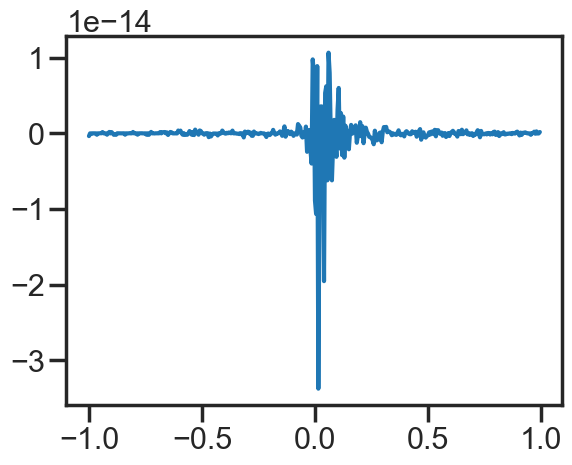

In [2]:
# First thing is a direct comparison between mHTP, HTP, and numba mHTP implementation.  

nu0     = 0 # Unperturbed line position in cm-1.
GammaD  = 35.1e-3     # Doppler broadening in cm-1.
Gamma0  = 11.7e-3     # Speed-averaged line-width in cm-1.
Gamma2  = 5.4e-3      # Quadratic speed dependence parameter of the line-width in cm-1.
Delta0  = 30.5e-3     # Speed-averaged line-shift in cm-1.
Delta2  = 12.4e-3     # Quadratic speed dependence parameter of the line-shift in cm-1.
NuOptRe = 38.0e-3     # Real part of the Dicke parameter in cm-1.
nuVC = NuOptRe
NuOptIm = 0#-017.5e-3    # Imaginary part of the Dicke parameter in cm-1.
eta =  0#- NuOptIm / Delta0
nu     = np.arange(-1, 1, 0.005)
Ylm = -1e-3 




hapi_lineshape, _ = MATS.hapi.pcqsdhc(nu0, GammaD, Gamma0, Gamma2, Delta0, Delta2,
                    nuVC, eta, nu, Ylm=Ylm)

mHTP_lineshape = MATS.mHT.profile.mHTprofile_vector(nu0, GammaD, Gamma0, Gamma2, 
                                                 Delta0, Delta2, NuOptRe, NuOptIm, nu, Ylm, 0, 10)

#mHTP_lineshape_2 = MATS.mHT.profile.mHTprofile_vector(nu0, GammaD, Gamma0, Gamma2, 
#                                                 Delta0, Delta2, NuOptRe, NuOptIm, nu, 0, 0, 10)

numba_mHTP_lineshape = MATS.mHT.numba_mHTP.mHTprofile_vector_numba(nu0, GammaD, Gamma0, Gamma2, 
                                                 Delta0, Delta2, NuOptRe, NuOptIm, nu, Ylm, 0, 10, 0)

plt.plot(nu, numba_mHTP_lineshape - mHTP_lineshape )
plt.show()





In [3]:
from MATS.linelistdata import linelistdata
PARAM_LINELIST = linelistdata['O2_ABand_Drouin_2017_linelist']

PARAM_LINELIST['eta_air'] = 0
PARAM_LINELIST['nuVC_air'] = 0.005

PARAM_LINELIST['nuOptRe_air'] = 0.005
PARAM_LINELIST['nuOptIm_air'] = 0

PARAM_LINELIST['n_nuOptRe_air'] = 0
PARAM_LINELIST['n_nuOptIm_air'] = 0
PARAM_LINELIST.reset_index(drop=True, inplace=True)

In [4]:
PARAM_LINELIST[(PARAM_LINELIST['nu'] > 13110) & (PARAM_LINELIST['nu'] < 13130) & (PARAM_LINELIST['sw'] >1e-24)]['SD_gamma_air']

42    0.10
43    0.12
44    0.08
45    0.07
46    0.08
Name: SD_gamma_air, dtype: float64

In [5]:
def simulate_and_fit(lineprofile, numba_lineprofile):


    #Generic Fit Parameters
    wave_range = 1.5 #range outside of experimental x-range to simulate
    IntensityThreshold = 1e-30 #intensities must be above this value to be simulated
    Fit_Intensity = 1e-24 #intensities must be above this value for the line to be fit
    order_baseline_fit = 1
    sample_molefraction = {7 :0.002022}
    wave_min = 13150 #cm-1
    wave_max = 13165 #cm-1
    wave_space = 0.005 #cm-1
    baseline_terms = [0] #polynomial baseline coefficients where the index is equal to the coefficient order
    
    #Error Sources
    ##SNR
    SNR = None
    
    
    
    wavenumbers = np.arange(wave_min, wave_max, wave_space)
    
    
    spec_1 =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = wavenumbers, lineprofile = lineprofile, numba_lineprofile = numba_lineprofile, sim_window = wave_range, 
                            SNR = SNR, baseline_terms = baseline_terms, temperature = 25, pressure = 10, 
                            wing_cutoff = 25,  wing_method = 'wing_wavenumbers', filename = '25_torr', molefraction = sample_molefraction, 
                            natural_abundance = True, nominal_temperature = 296, IntensityThreshold = 1e-30, num_segments = 1)
    spec_2 =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = wavenumbers,lineprofile = lineprofile, numba_lineprofile = numba_lineprofile, sim_window = wave_range, 
                            SNR = SNR, baseline_terms = baseline_terms, temperature = 25, pressure = 100, 
                            wing_cutoff = 25,  wing_method = 'wing_wavenumbers', filename = '25_torr', molefraction = sample_molefraction, 
                            natural_abundance = True, nominal_temperature = 296, IntensityThreshold = 1e-30, num_segments = 1)
    spec_3 =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = wavenumbers,lineprofile = lineprofile, numba_lineprofile = numba_lineprofile, sim_window = wave_range, 
                            SNR = SNR, baseline_terms = baseline_terms, temperature = 25, pressure = 500, 
                            wing_cutoff = 25,  wing_method = 'wing_wavenumbers', filename = '25_torr', molefraction = sample_molefraction, 
                            natural_abundance = True, nominal_temperature = 296, IntensityThreshold = 1e-30, num_segments = 1)
    
    
    
    #Add all spectrum to a Dataset object
    SPECTRA = MATS.Dataset([spec_1, spec_2, spec_3], 'Line Intensity', PARAM_LINELIST)
    
    #Generate Baseline Parameter list based on number of etalons in spectra definitions and baseline order
    BASE_LINELIST = SPECTRA.generate_baseline_paramlist()
    
    FITPARAMS = MATS.Generate_FitParam_File(SPECTRA, PARAM_LINELIST, BASE_LINELIST, lineprofile = lineprofile, linemixing = True, 
                                      fit_intensity = Fit_Intensity, threshold_intensity = IntensityThreshold, sim_window = wave_range,
                                      nu_constrain = True, sw_constrain = True, gamma0_constrain = True, delta0_constrain = True, 
                                       aw_constrain = True, as_constrain = True, 
                                       nuVC_constrain = True, eta_constrain =True, linemixing_constrain = True)
    
    FITPARAMS.generate_fit_param_linelist_from_linelist(vary_nu = {7:{1:True, 2:False, 3:False}}, vary_sw = {7:{1:True, 2:False, 3:False}},
                                                        vary_gamma0 = {7:{1: True, 2:False, 3: False}, 1:{1:False}}, vary_n_gamma0 = {7:{1:False}}, 
                                                        vary_delta0 = {7:{1: True, 2:False, 3: False}, 1:{1:False}}, vary_n_delta0 = {7:{1:False}}, 
                                                        vary_aw = {7:{1: True, 2:False, 3: False}, 1:{1:False}}, vary_n_gamma2 = {7:{1:False}}, 
                                                        vary_as = {}, vary_n_delta2 = {7:{1:False}}, 
                                                        vary_nuVC = {7:{1:True}}, vary_n_nuVC = {7:{1:False}},
                                                        vary_nuOptRe = {7:{1:True}}, 
                                                        vary_eta = {7:{1:False}}, vary_linemixing = {7:{1:True}})
    
    FITPARAMS.generate_fit_baseline_linelist(vary_baseline = False, vary_molefraction = {7:False, 1:False}, vary_xshift = False, 
                                          vary_etalon_amp= False, vary_etalon_period= False, vary_etalon_phase= False, 
                                             vary_pressure = False, vary_temperature = False)
    
    
    
    Parameter_LineList = pd.read_csv('Parameter_LineList.csv', index_col = 0)
    
    
    for index in Parameter_LineList[(Parameter_LineList['sw']>1) & (Parameter_LineList['nu']<wave_max) & (Parameter_LineList['nu']>wave_min)].index.unique():
        #Parameter_LineList.loc[Parameter_LineList.index == index, 'nu'] = Parameter_LineList[Parameter_LineList.index == index]['nu'].values[0] + np.random.normal(loc = 0, scale =0.005) #adjust by random number scale 0.005 cm-1
        Parameter_LineList.loc[Parameter_LineList.index == index, 'sw'] = Parameter_LineList[Parameter_LineList.index == index]['sw'].values[0]*(1 + np.random.normal(loc = 0, scale =0.01)) # adjust by random amount at 1% scale
        Parameter_LineList.loc[Parameter_LineList.index == index, 'gamma0_air'] = Parameter_LineList[Parameter_LineList.index == index]['gamma0_air'].values[0]*(1 + np.random.normal(loc = 0, scale =0.01)) # adjust by random amount at 1% scale
        Parameter_LineList.loc[Parameter_LineList.index == index, 'delta0_air'] = Parameter_LineList[Parameter_LineList.index == index]['delta0_air'].values[0]*(1 + np.random.normal(loc = 0, scale =0.02)) # adjust by random amount at 2% scale
        Parameter_LineList.loc[Parameter_LineList.index == index, 'SD_gamma_air'] = Parameter_LineList[Parameter_LineList.index == index]['SD_gamma_air'].values[0]*(1 + np.random.normal(loc = 0, scale =0.1)) # adjust by random amount at 10% scale
    
    Parameter_LineList.to_csv('Parameter_LineList.csv')
    
    fit_data = MATS.Fit_DataSet(SPECTRA,'Baseline_LineList', 'Parameter_LineList', lineprofile = lineprofile, numba_lineprofile = numba_lineprofile,
                                minimum_parameter_fit_intensity = Fit_Intensity)
    params = fit_data.generate_params()
    result = fit_data.fit_data(params, wing_cutoff = 25,  wing_method = 'wing_wavenumbers')
    fit_data.residual_analysis(result, indv_resid_plot=False)
    fit_data.update_params(result)
    SPECTRA.generate_summary_file(save_file = True)
    SPECTRA.plot_model_residuals()
    print (result.params.pretty_print())

    return result, PARAM_LINELIST


    
    


In [8]:
import time

def run_performance_test(method_name, lineprofile, numba_lineprofile, iterations=8):
    print(f"\n--- Starting Performance Test: {method_name} ---")
    
    times = []
    results_list = []
    
    # Add any other parameters you want to track here
    track_params = ['sw', 'gamma0_air', 'delta0_air', 'SD_gamma_air', 'nuOptRe_air', 'nuVC_air'] 
    
    for i in range(iterations):
        # Time the execution
        start_time = time.perf_counter()
        
        # Run the engine
        result, truth_linelist = simulate_and_fit(lineprofile, numba_lineprofile)
        
        end_time = time.perf_counter()
        execution_time = end_time - start_time
        times.append(execution_time)
        
        # --- THE FIX: FIND ALL UNIQUE LINE INDICES ---
        fit_line_indices = set()
        for key in result.params.keys():
            if '_line_' in key:
                try:
                    # Extract the integer at the end of the string
                    idx = int(key.split('_line_')[-1])
                    fit_line_indices.add(idx)
                except ValueError:
                    pass
                    
        if not fit_line_indices:
            print(f"Warning: No lines were floated in iteration {i+1}!")
            continue
            
        # Extract data for EVERY line found
        for line_idx in sorted(list(fit_line_indices)):
            line_data = {
                'Iteration': i + 1, 
                'Time (s)': execution_time, 
                'Line_Index': line_idx
            }
            
            for param in track_params:
                param_key = f'{param}_line_{line_idx}'
                
                if (param_key in result.params):
                    if result.params[param_key].vary:
                        fit_val = result.params[param_key].value
                        truth_val = truth_linelist.loc[line_idx, param]
                        
                        line_data[f'{param}_Fit'] = fit_val
                        line_data[f'{param}_Truth'] = truth_val
                        
                        # Protect against division by zero for % error
                        if truth_val != 0:
                            line_data[f'{param}_%Error'] = ((fit_val - truth_val) / truth_val) * 100
                        else:
                            line_data[f'{param}_%Error'] = np.nan
                
            results_list.append(line_data)
            
        print(f"Iteration {i+1} completed in {execution_time:.3f} s (Extracted {len(fit_line_indices)} lines)")

    # Calculate Timing Stats
    mean_time = np.mean(times)
    std_time = np.std(times)
    print(f"\n{method_name} Timing: {mean_time:.3f} s +/- {std_time:.3f} s")
    
    # Create the Summary DataFrame
    df_results = pd.DataFrame(results_list)
    df_results.to_csv(f'Performance_Test_{method_name}.csv', index=False)
    
    return df_results


--- Starting Performance Test: HTP_Standard ---
For HTP lineprofile make use of vary_nuVC, vary_n_nuVCm and vary_eta parameters


C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


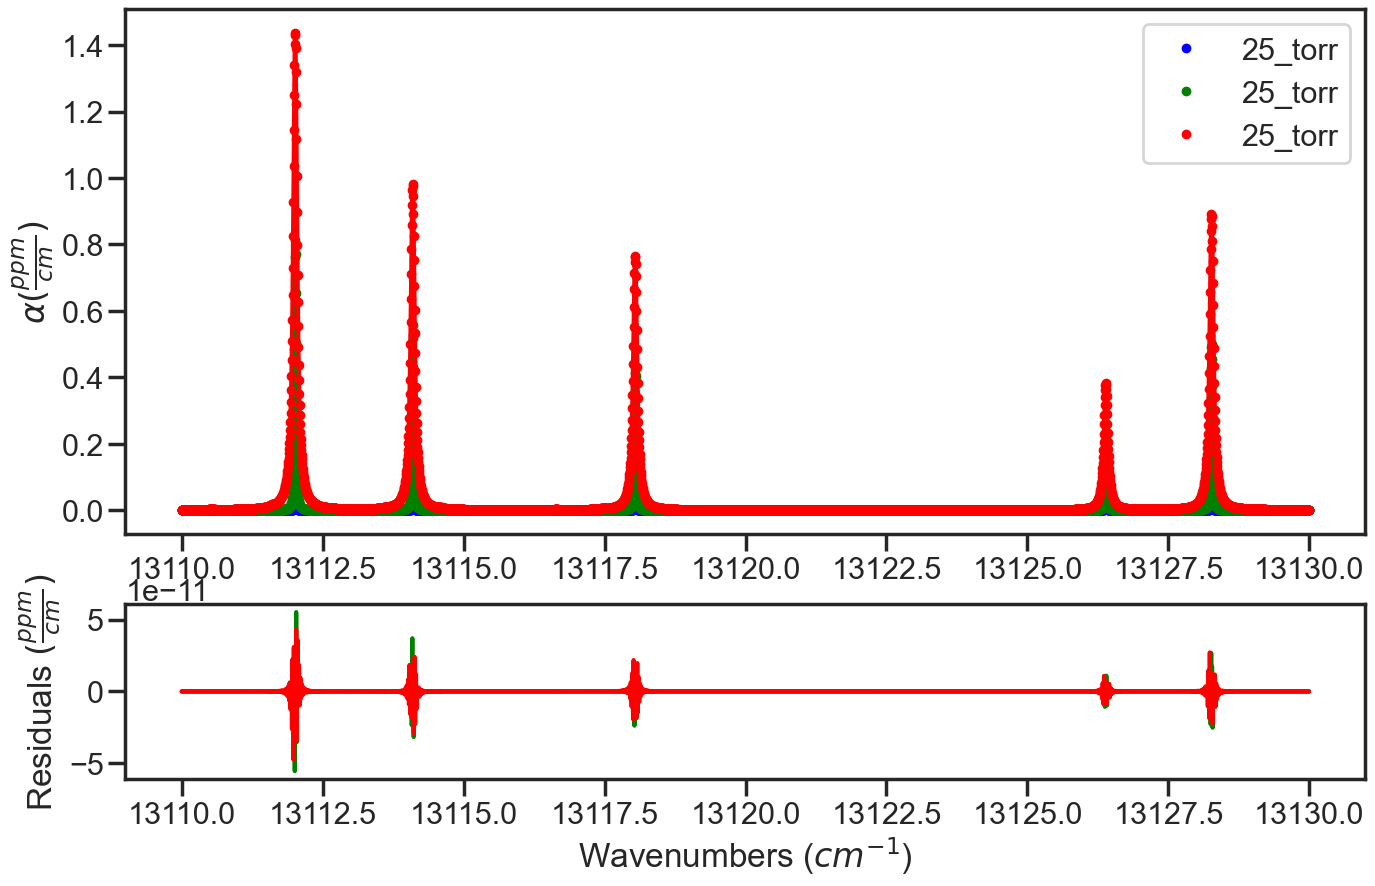

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.864e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.569e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


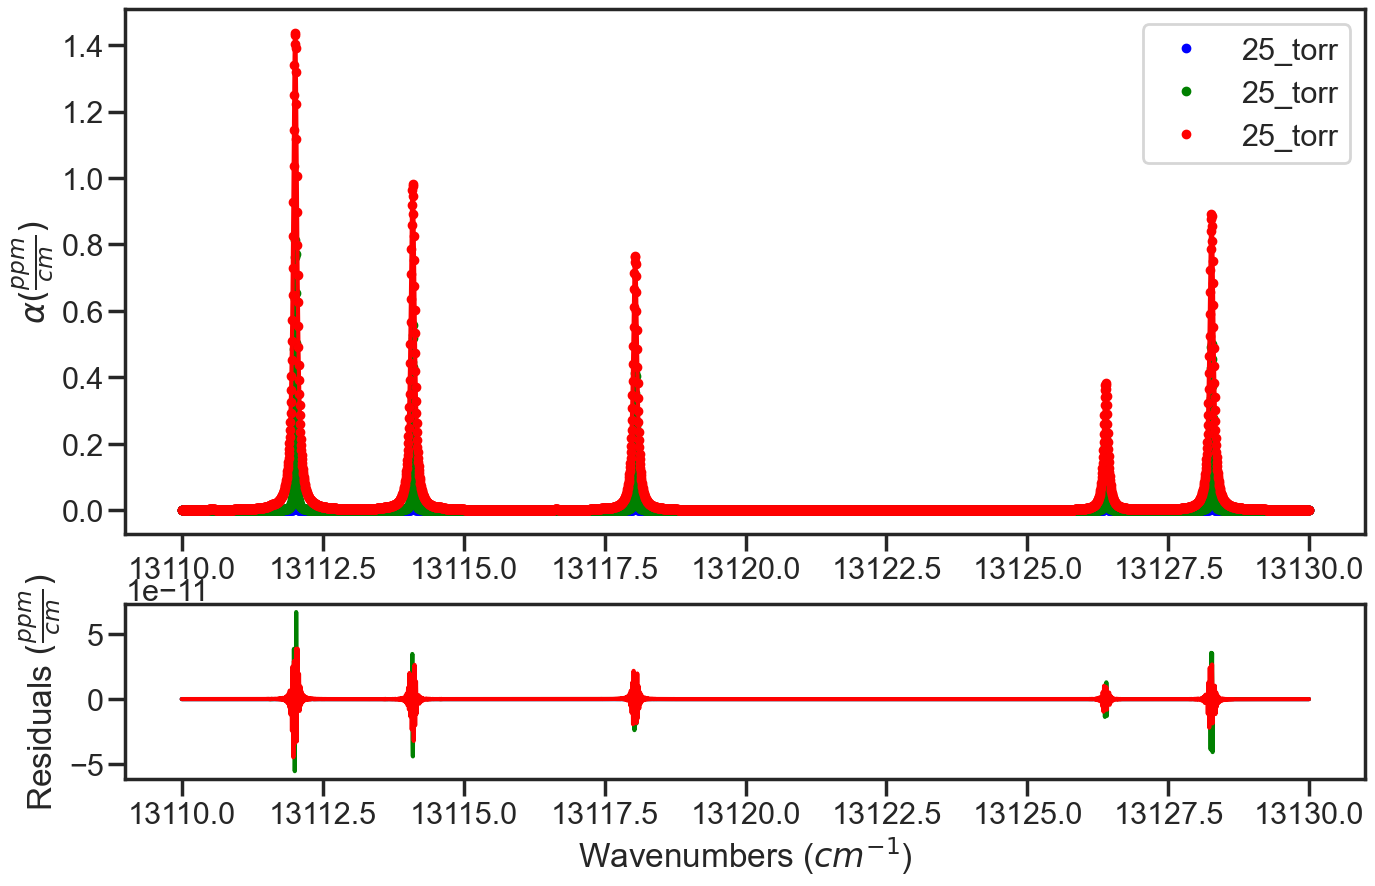

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 7.899e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 9.86e-12     

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


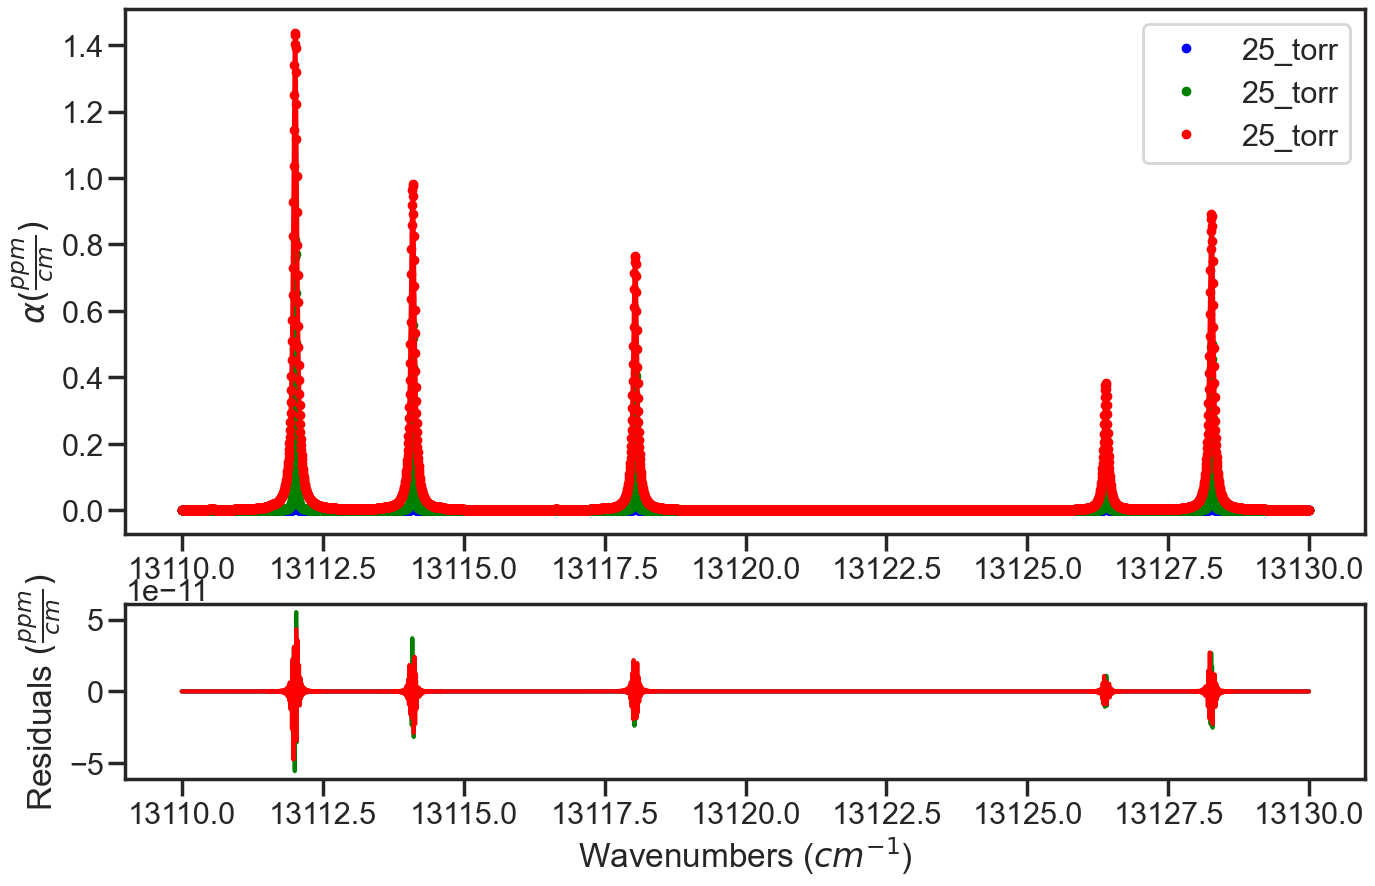

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.864e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.569e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


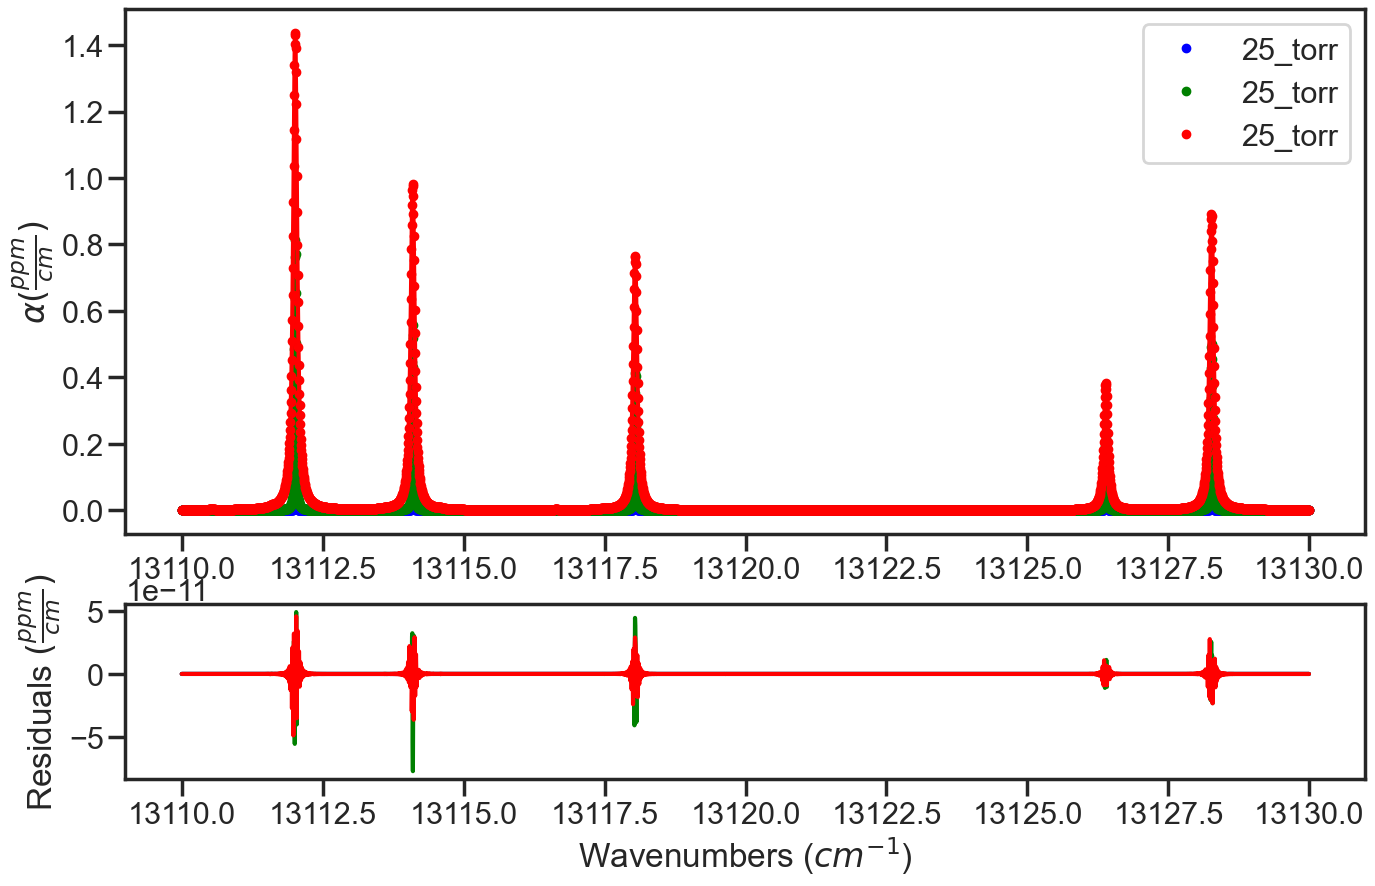

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 8.718e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 1.088e-11    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For HTP lineprofile make use of vary_nuVC, vary_n_nuVCm and vary_eta parameters


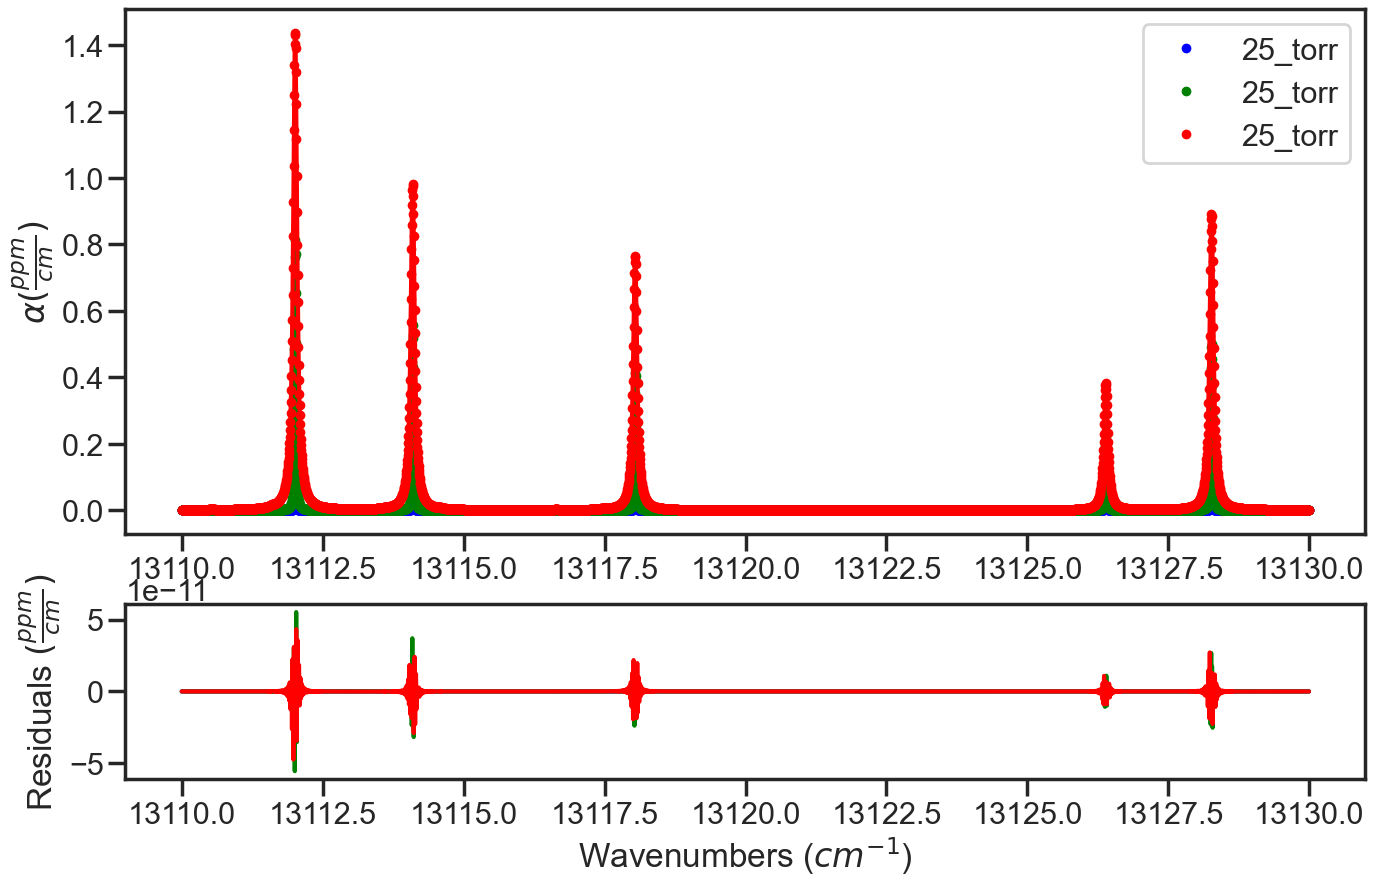

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.864e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.569e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


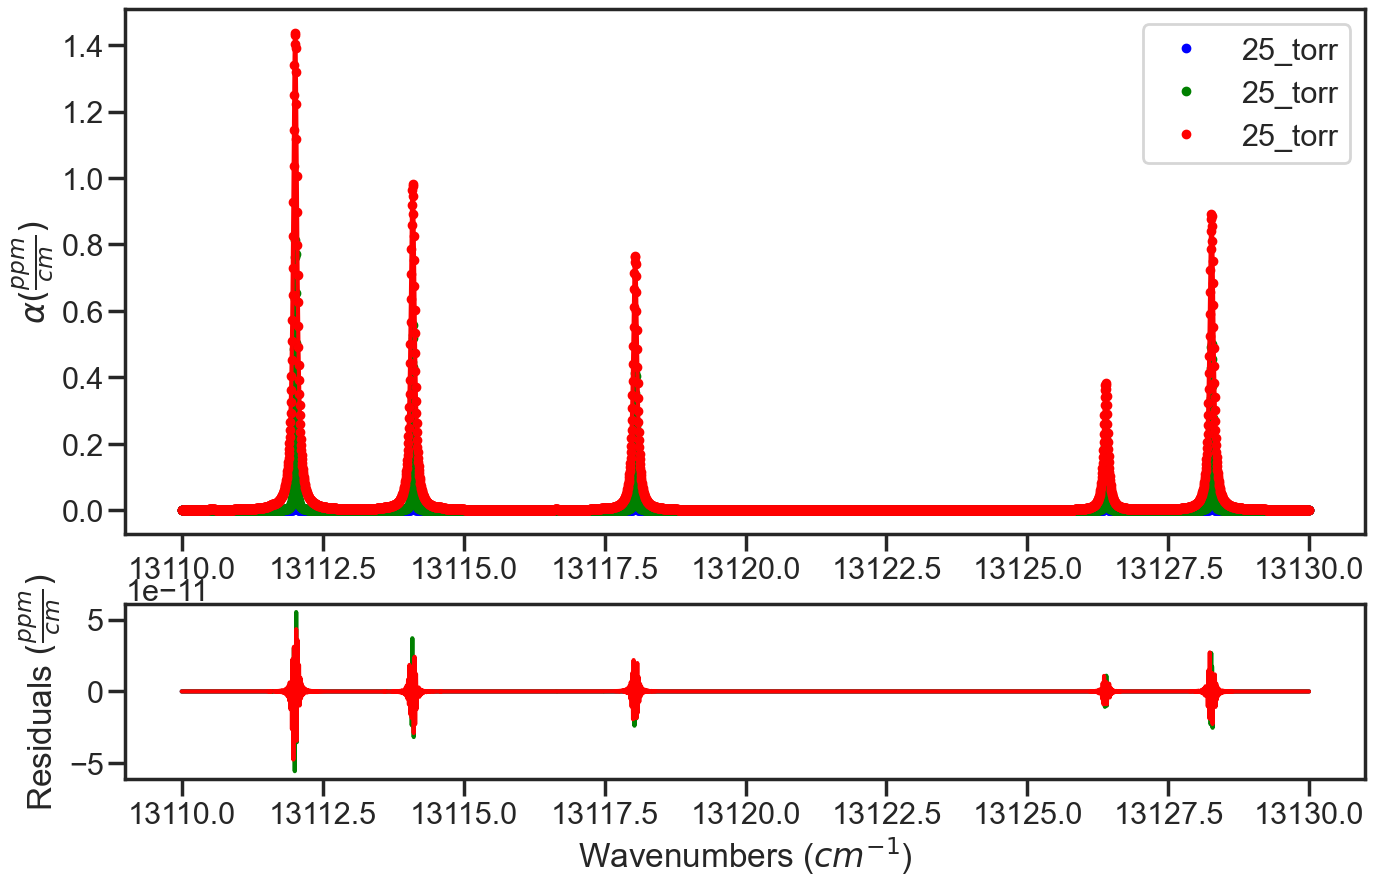

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.864e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.569e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


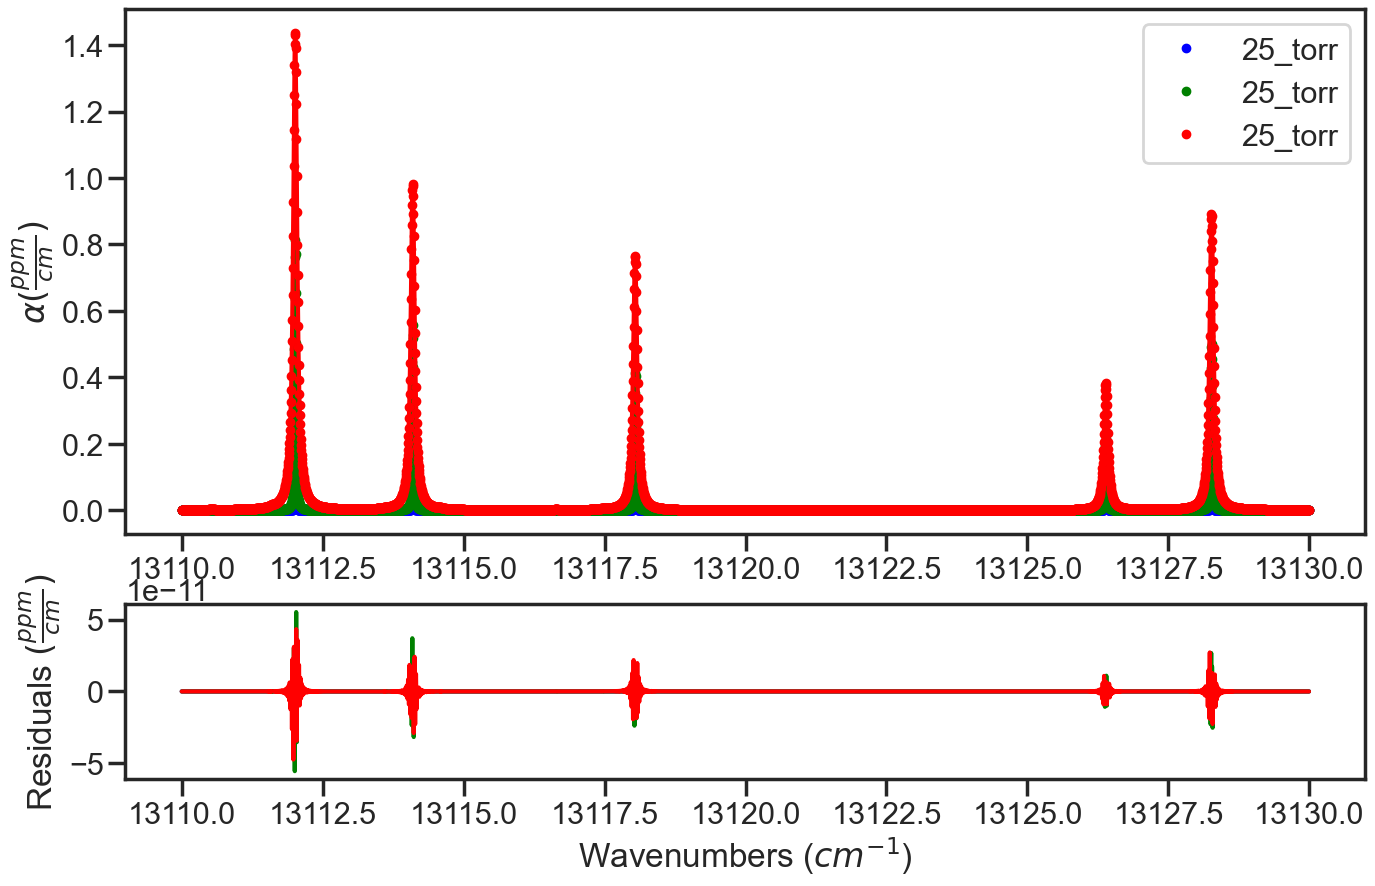

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.864e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.569e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


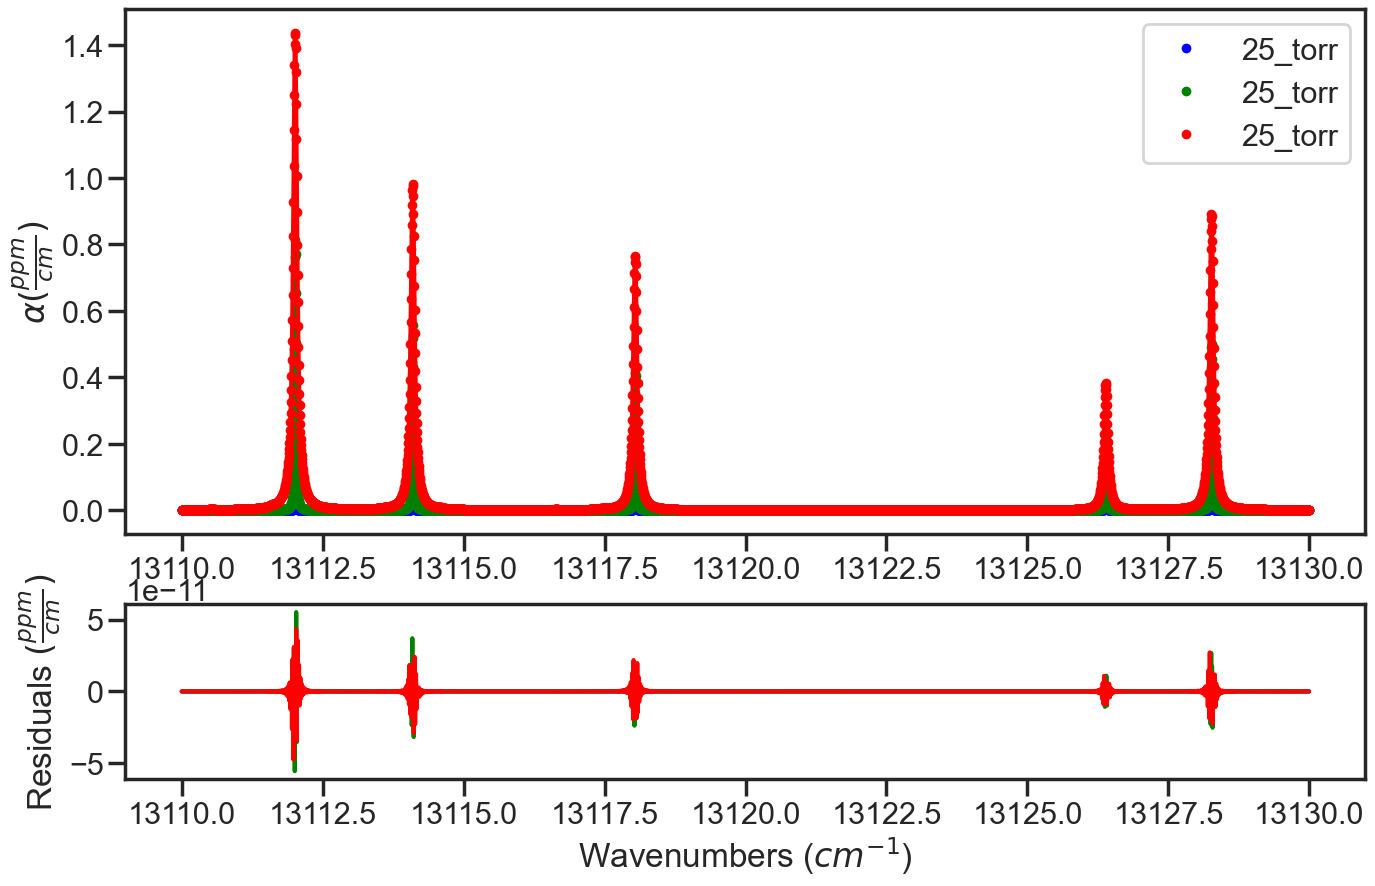

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.864e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.569e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


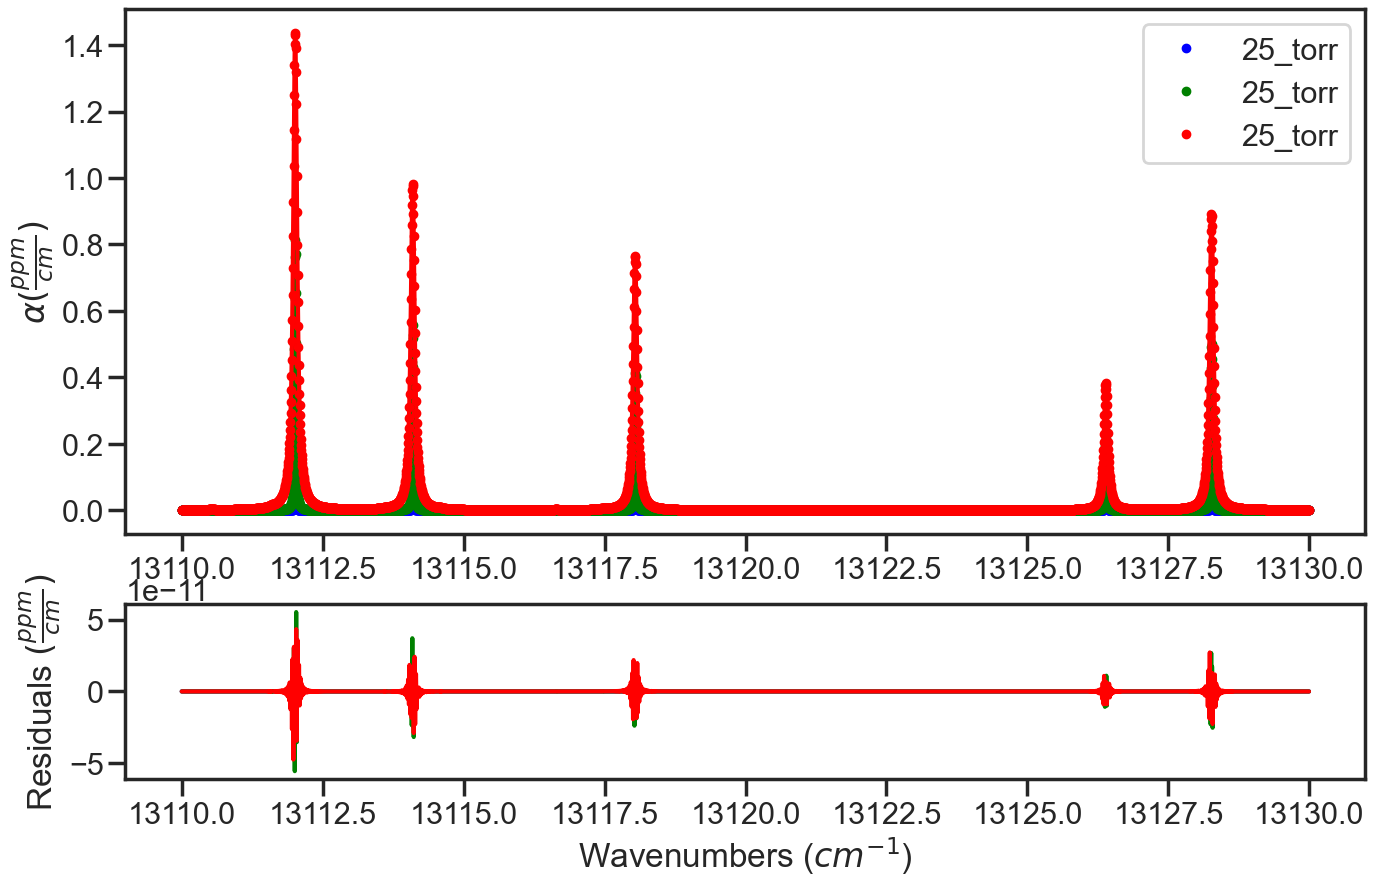

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.864e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.569e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For HTP lineprofile make use of vary_nuVC, vary_n_nuVCm and vary_eta parameters


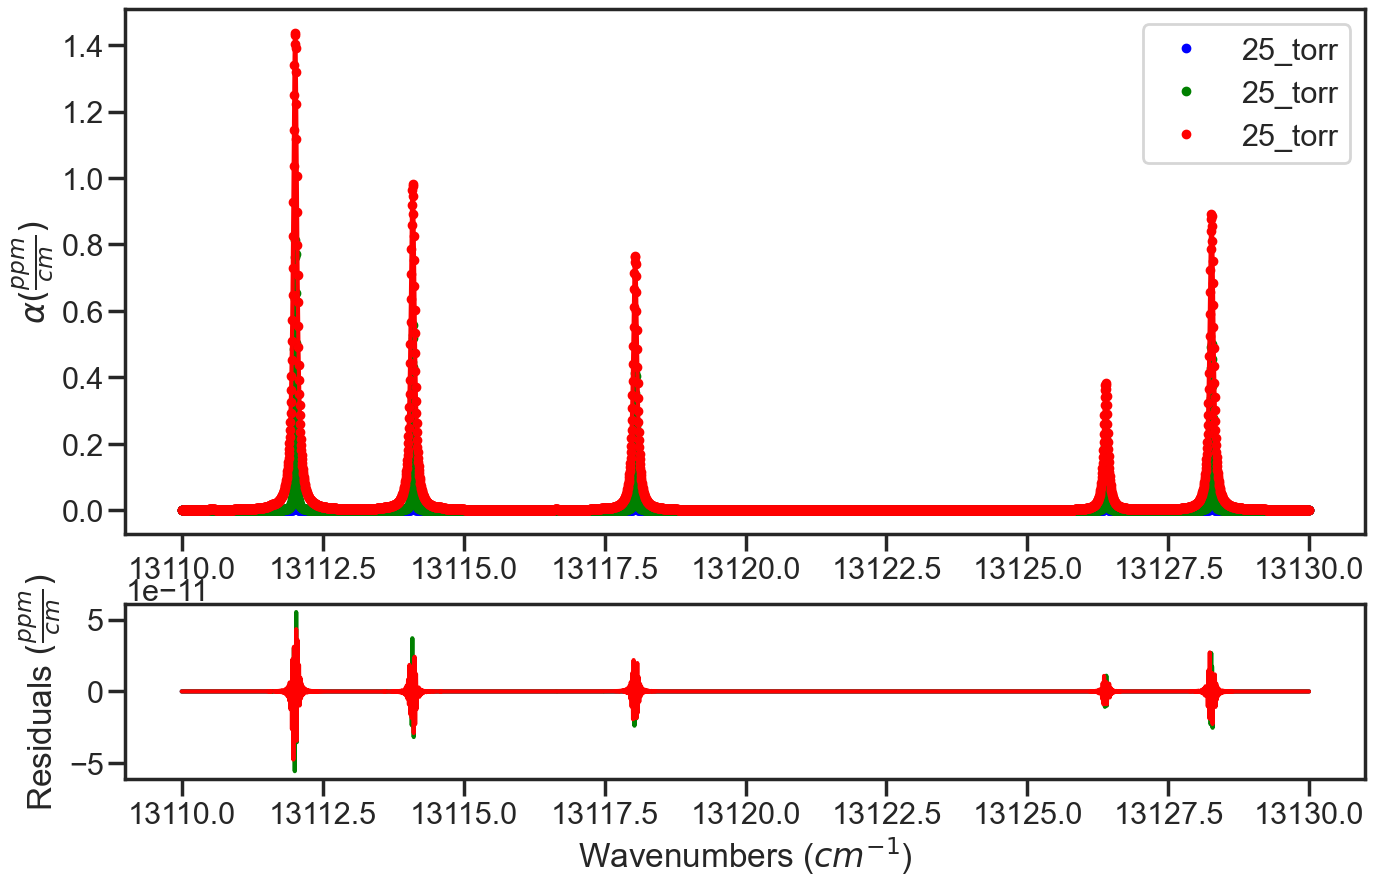

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.864e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.569e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


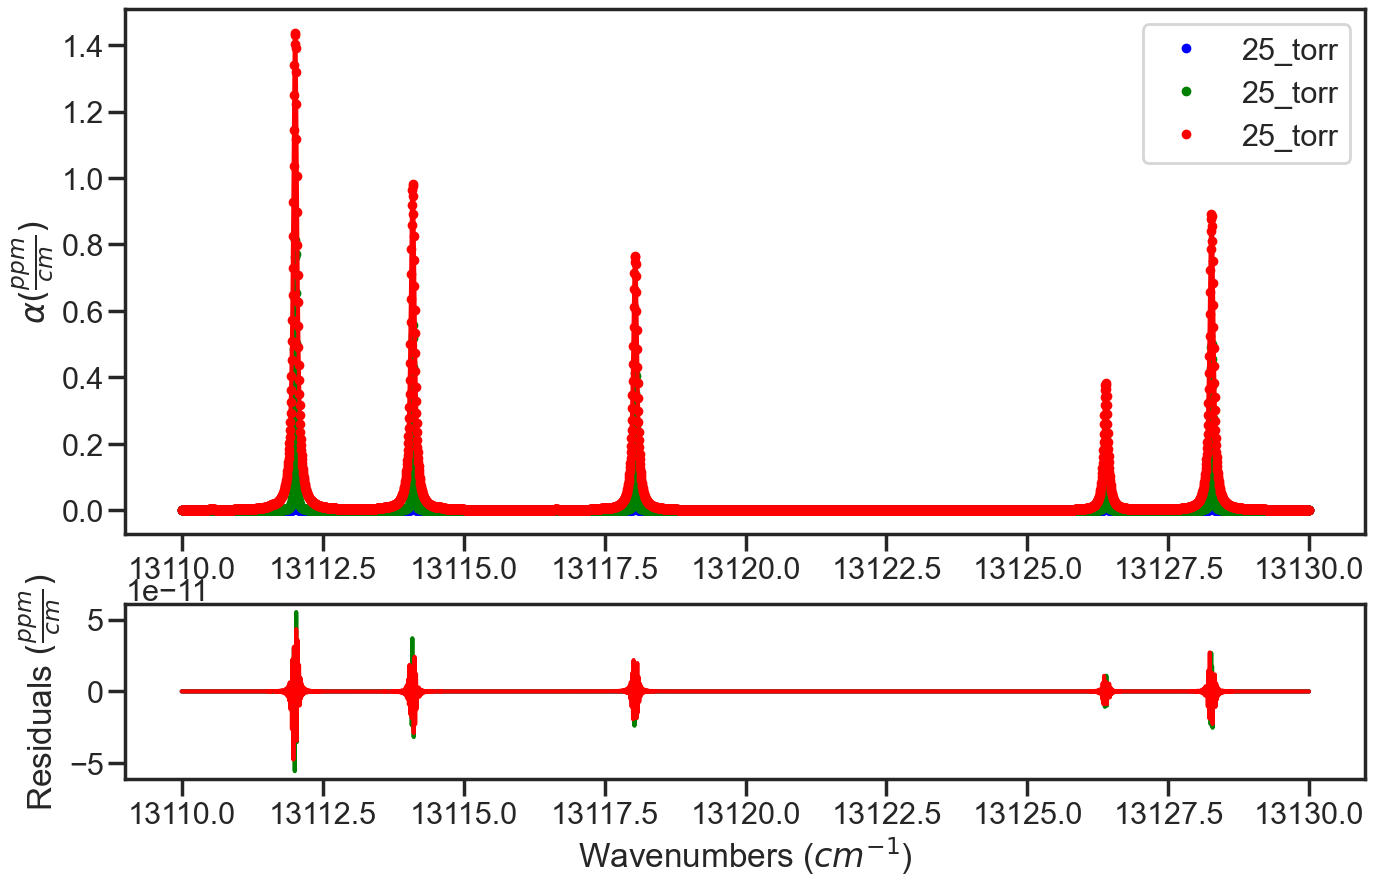

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


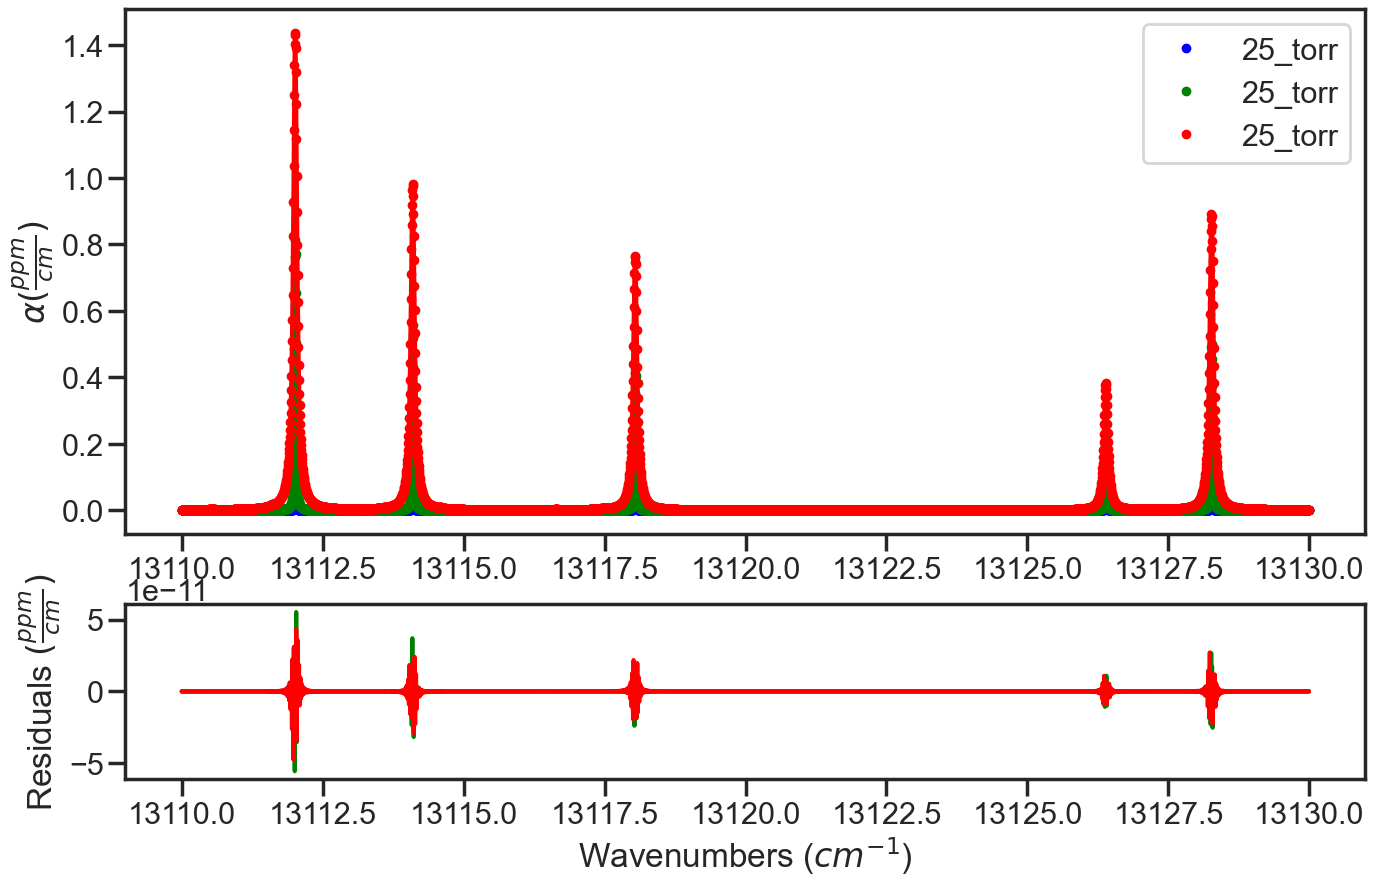

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


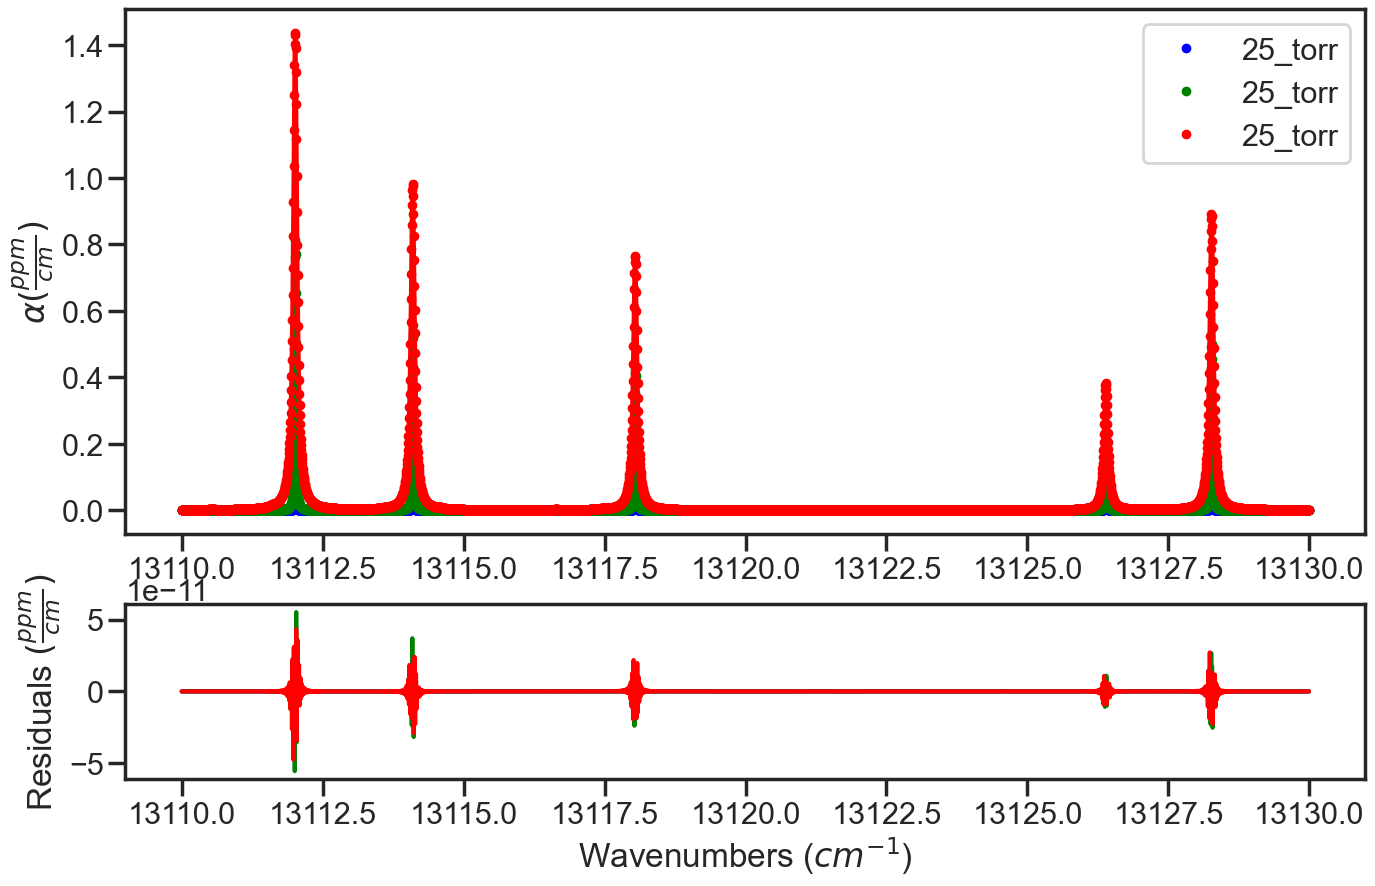

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


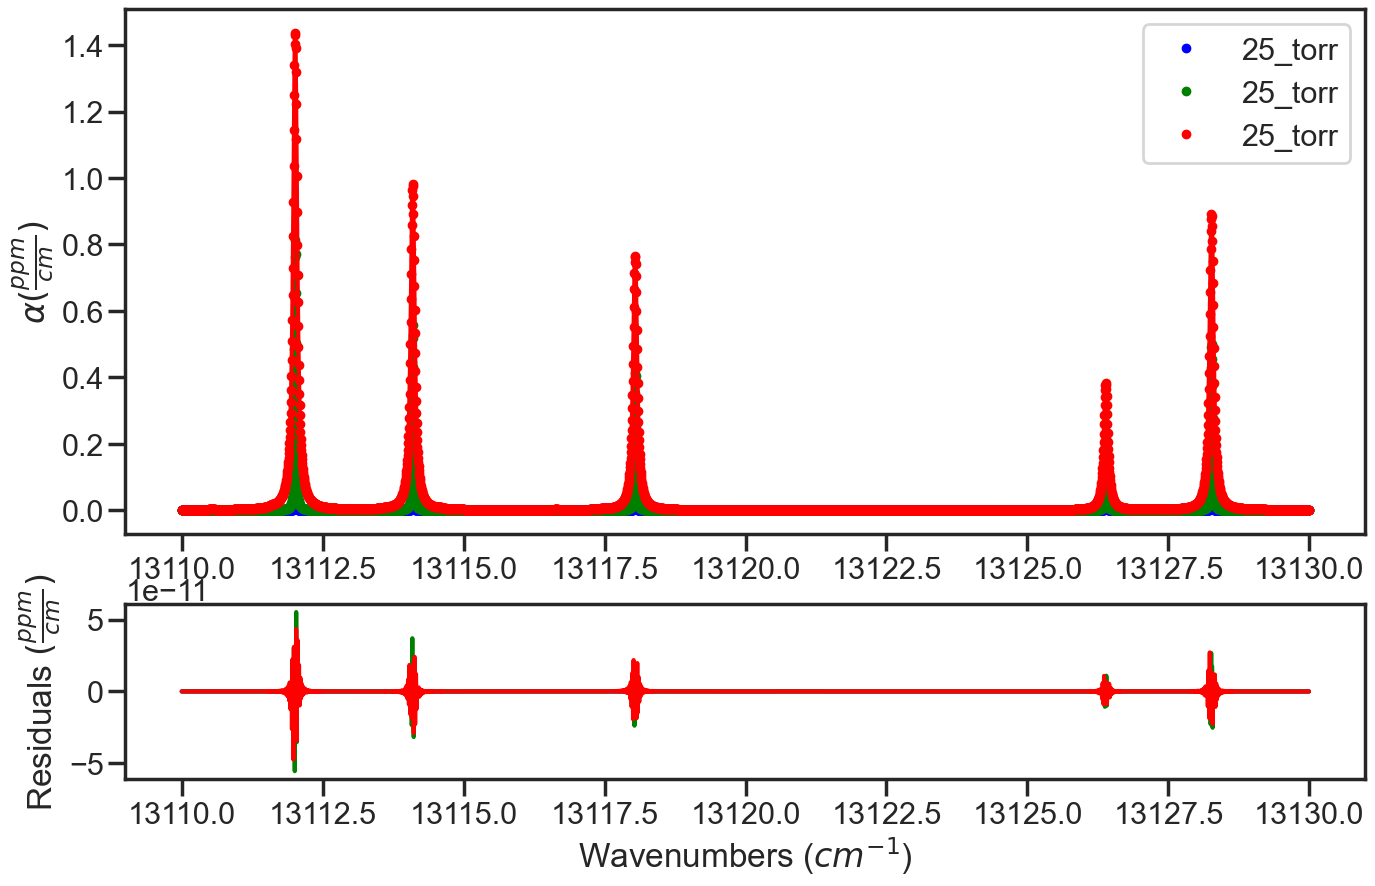

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


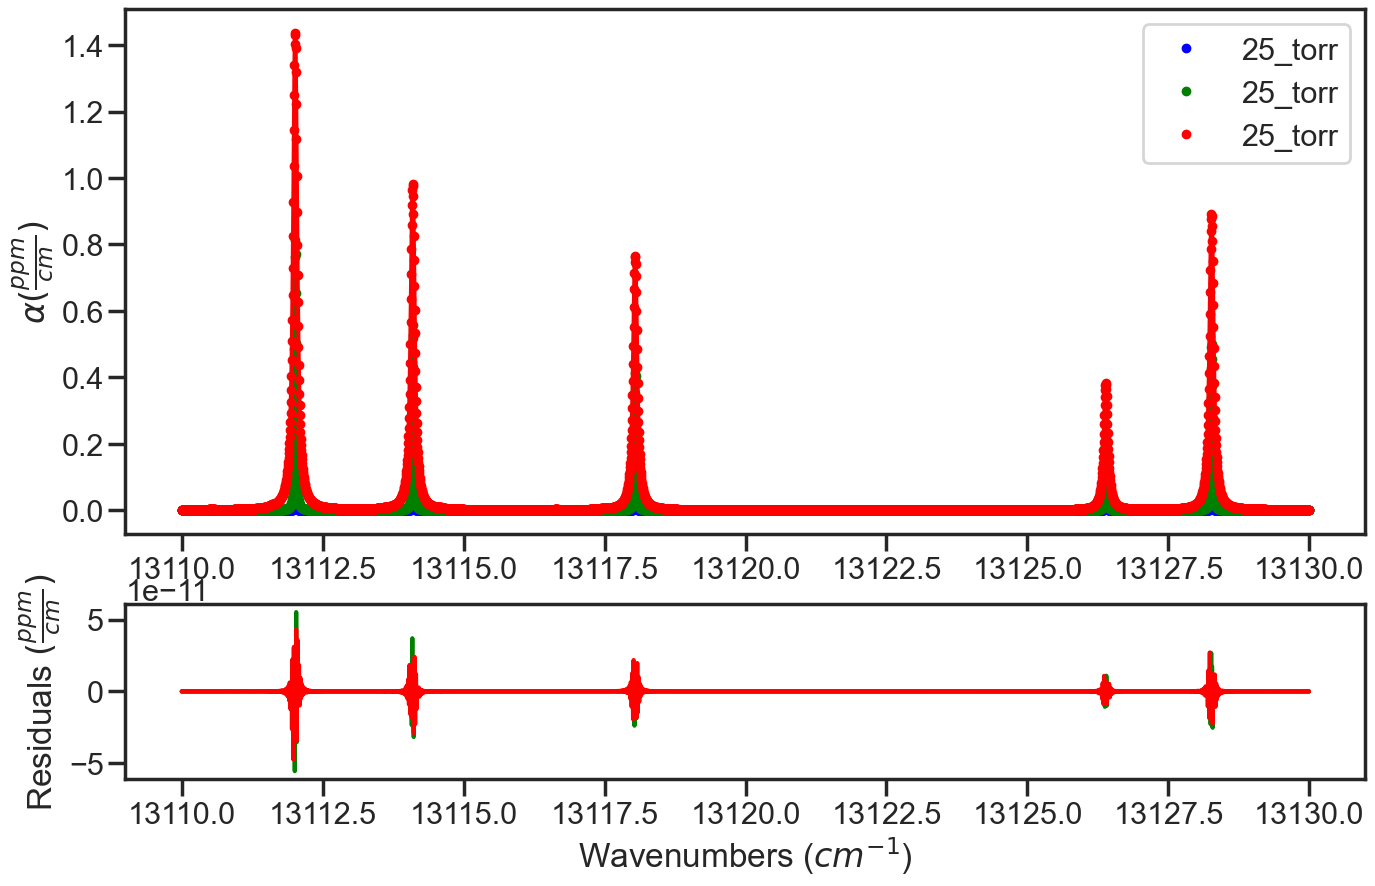

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


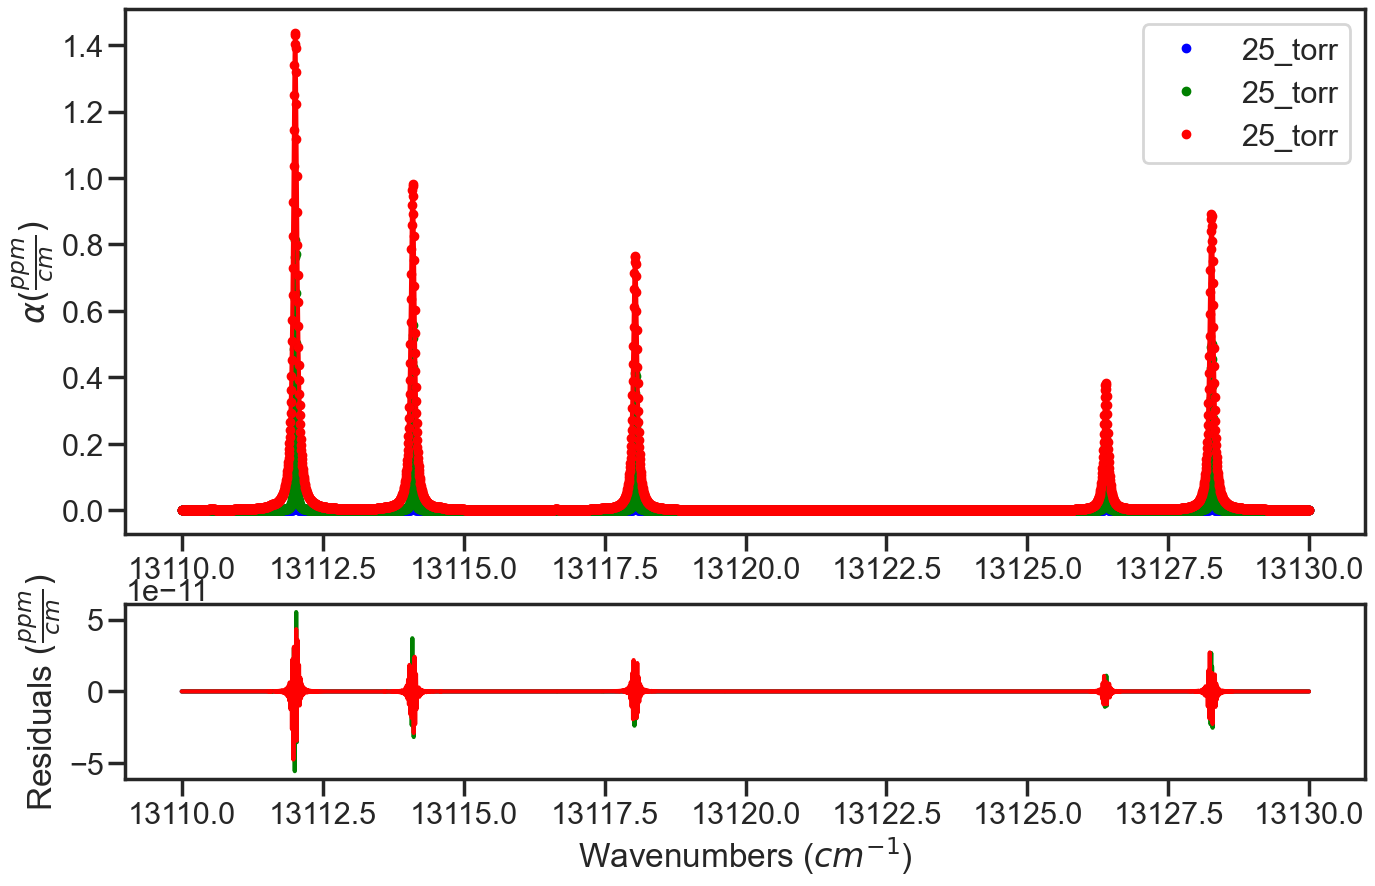

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


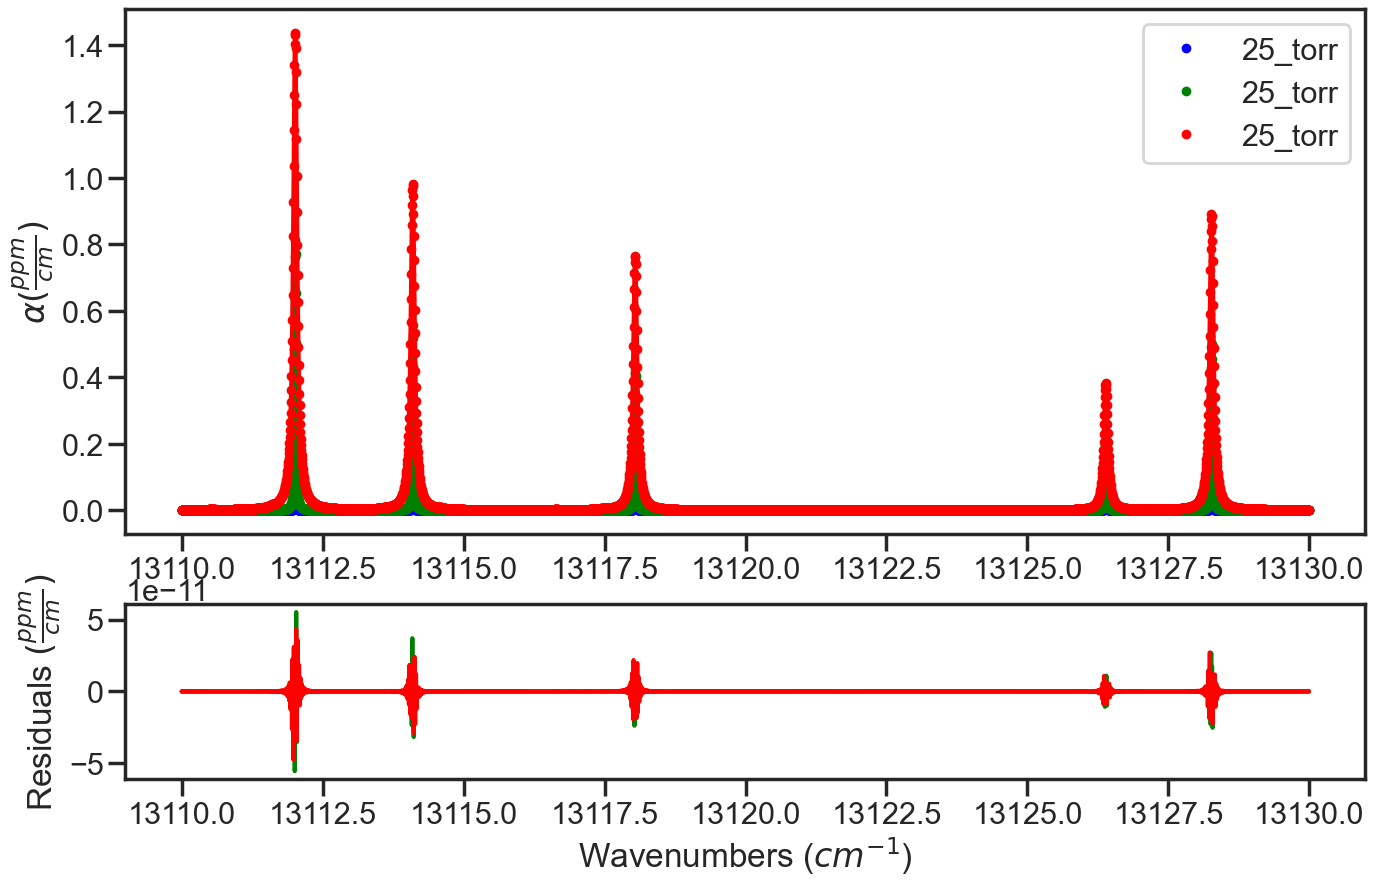

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


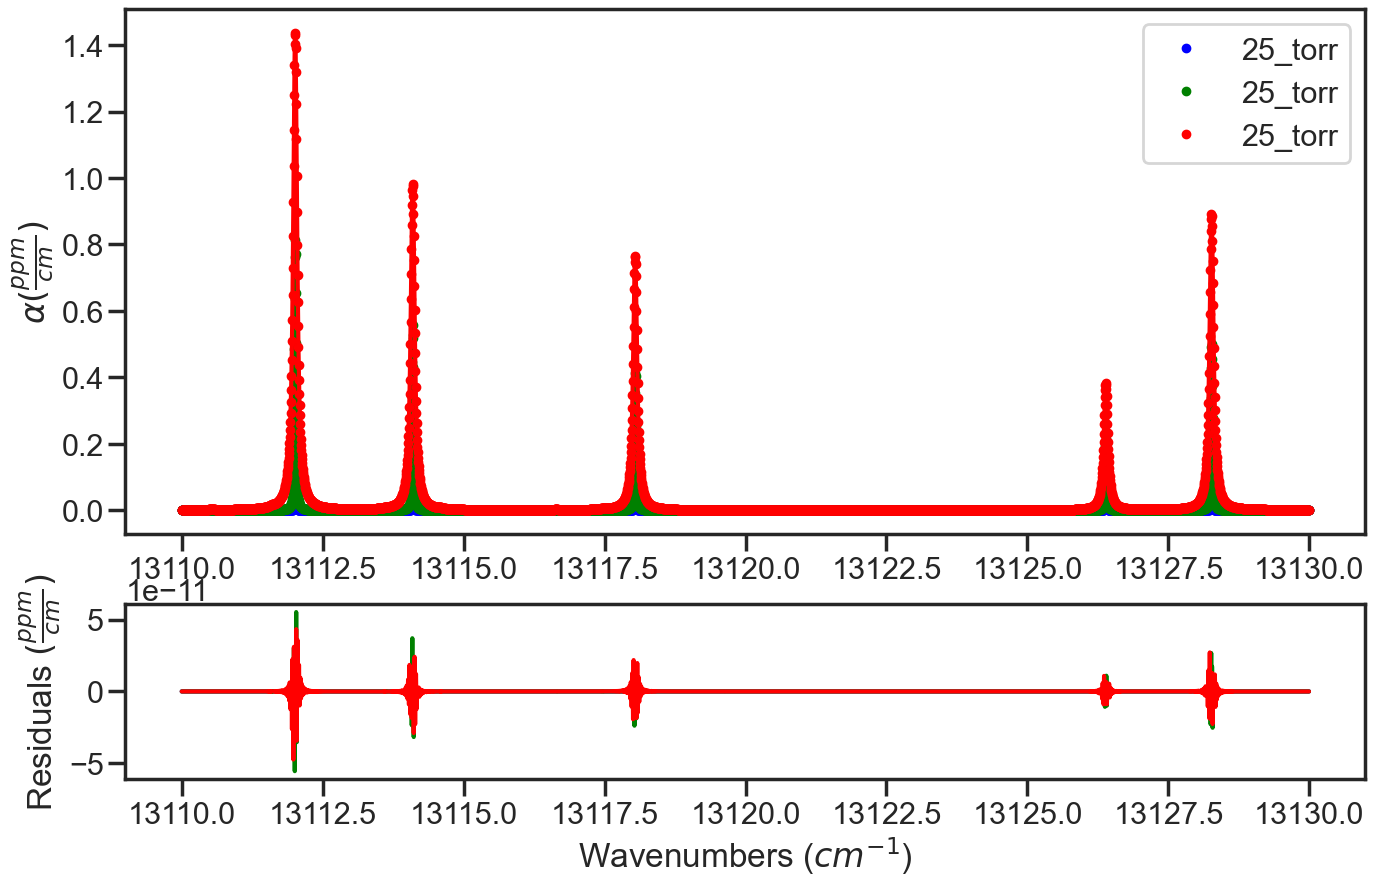

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


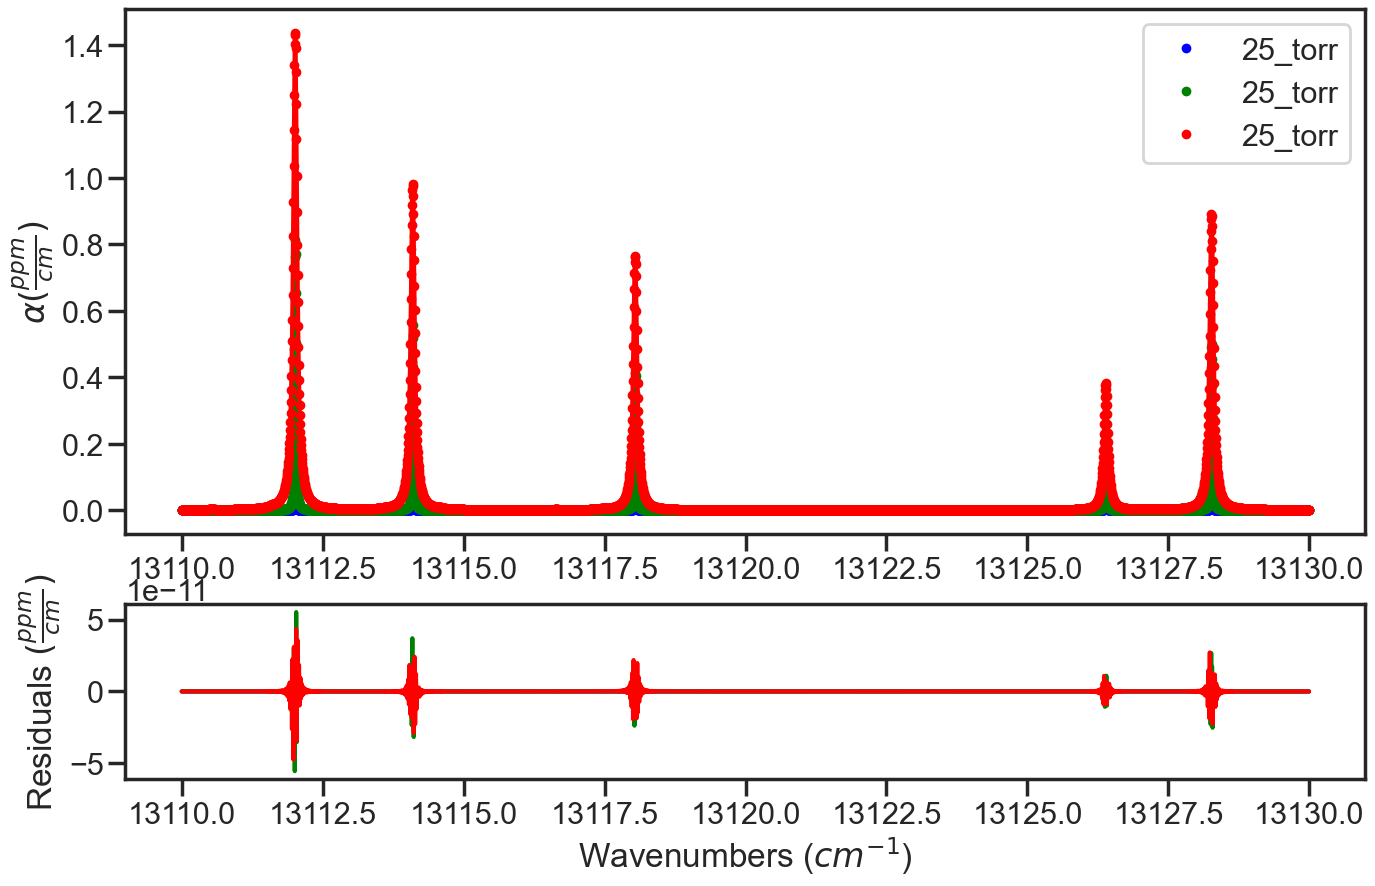

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


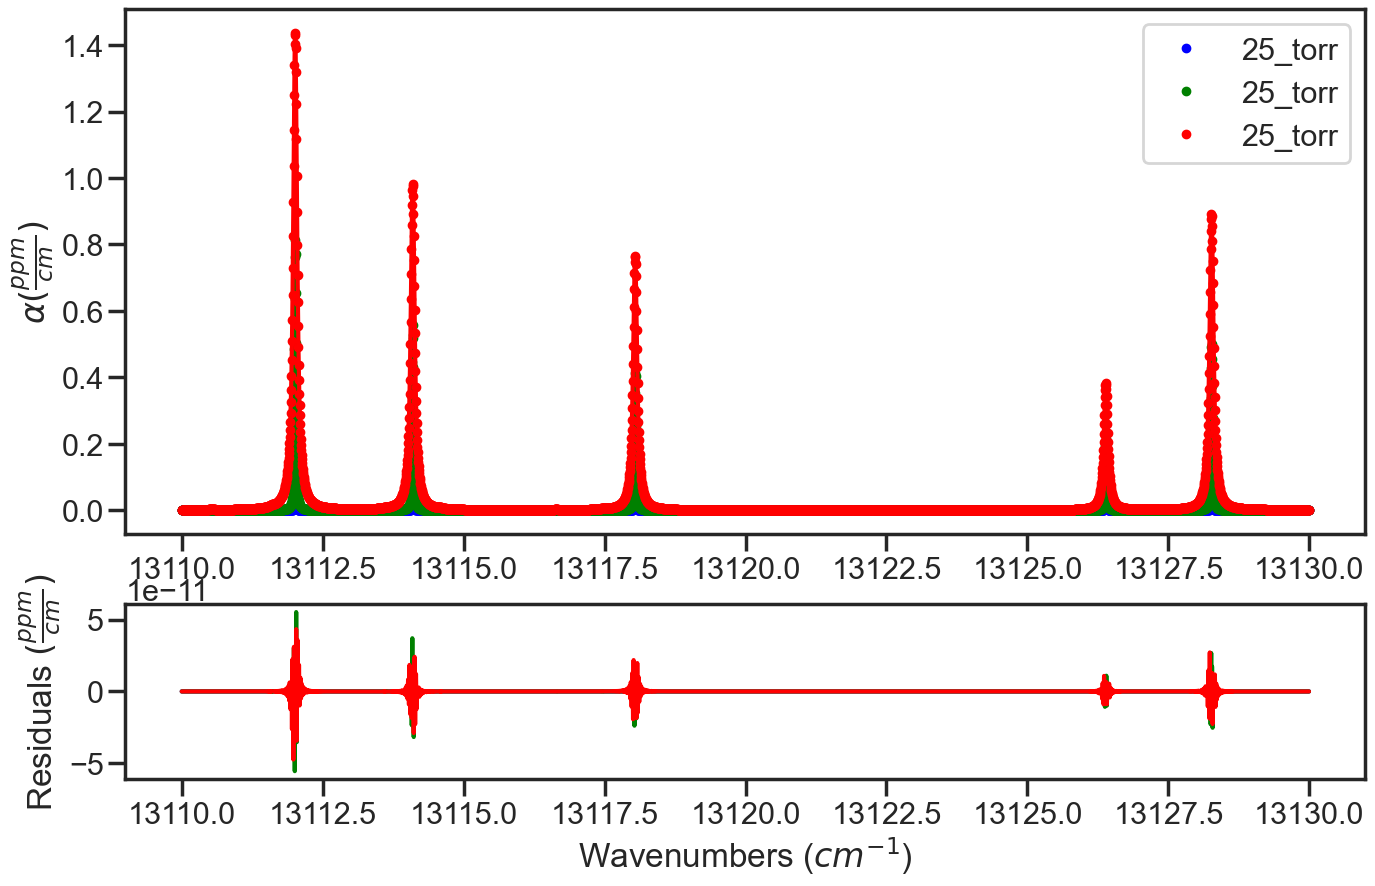

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


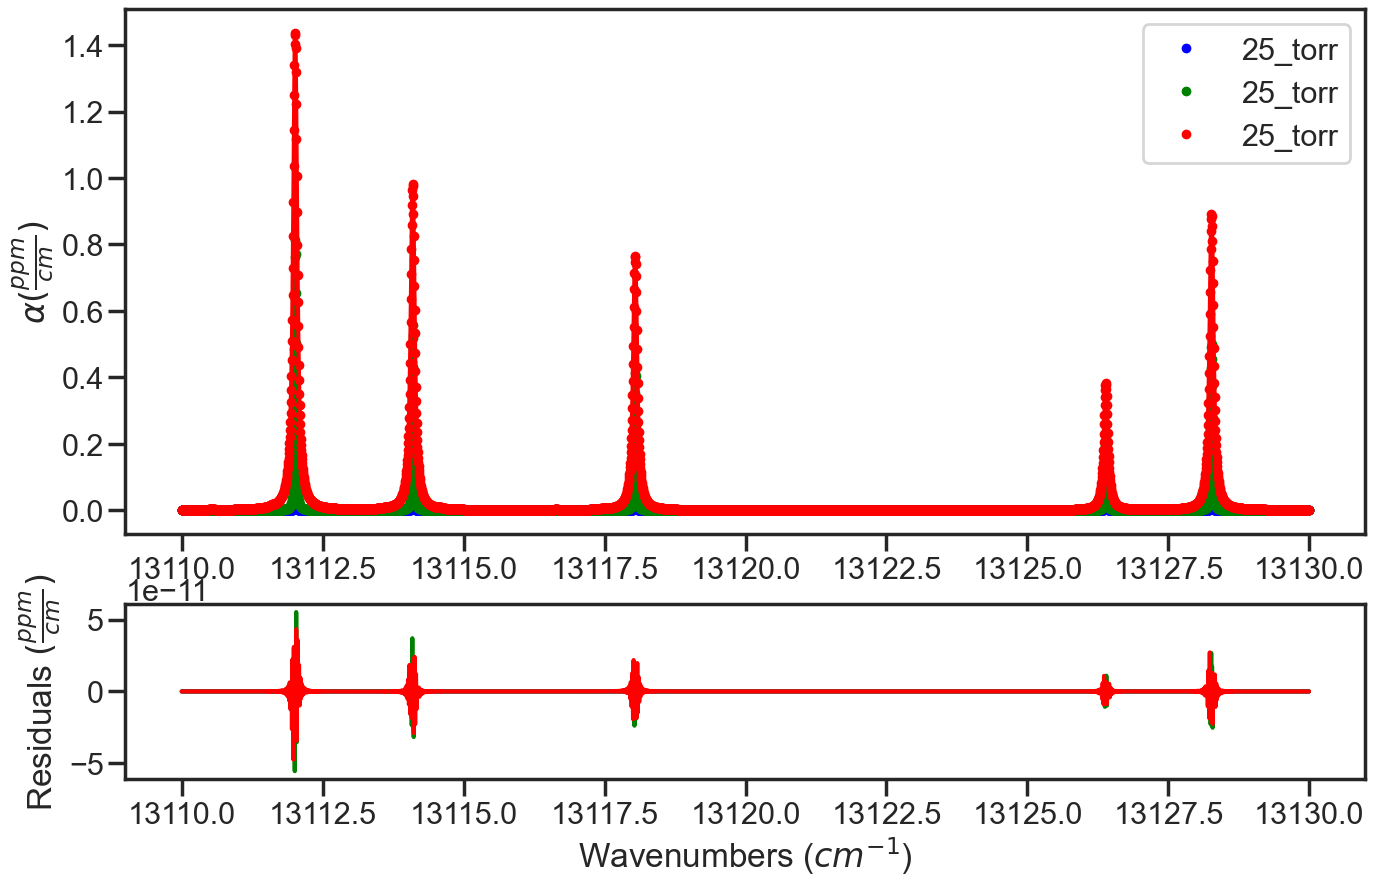

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


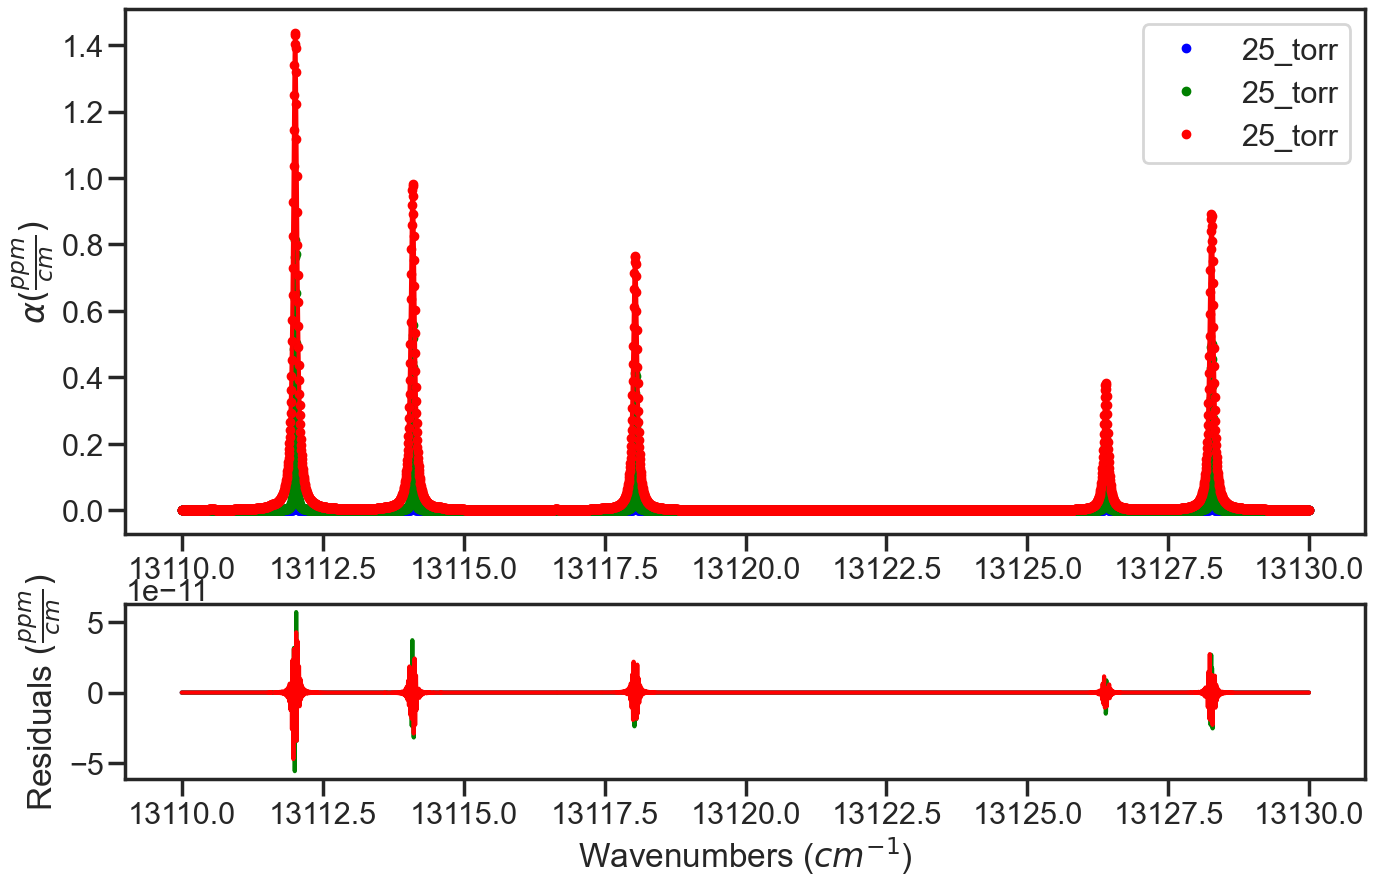

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.895e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.611e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


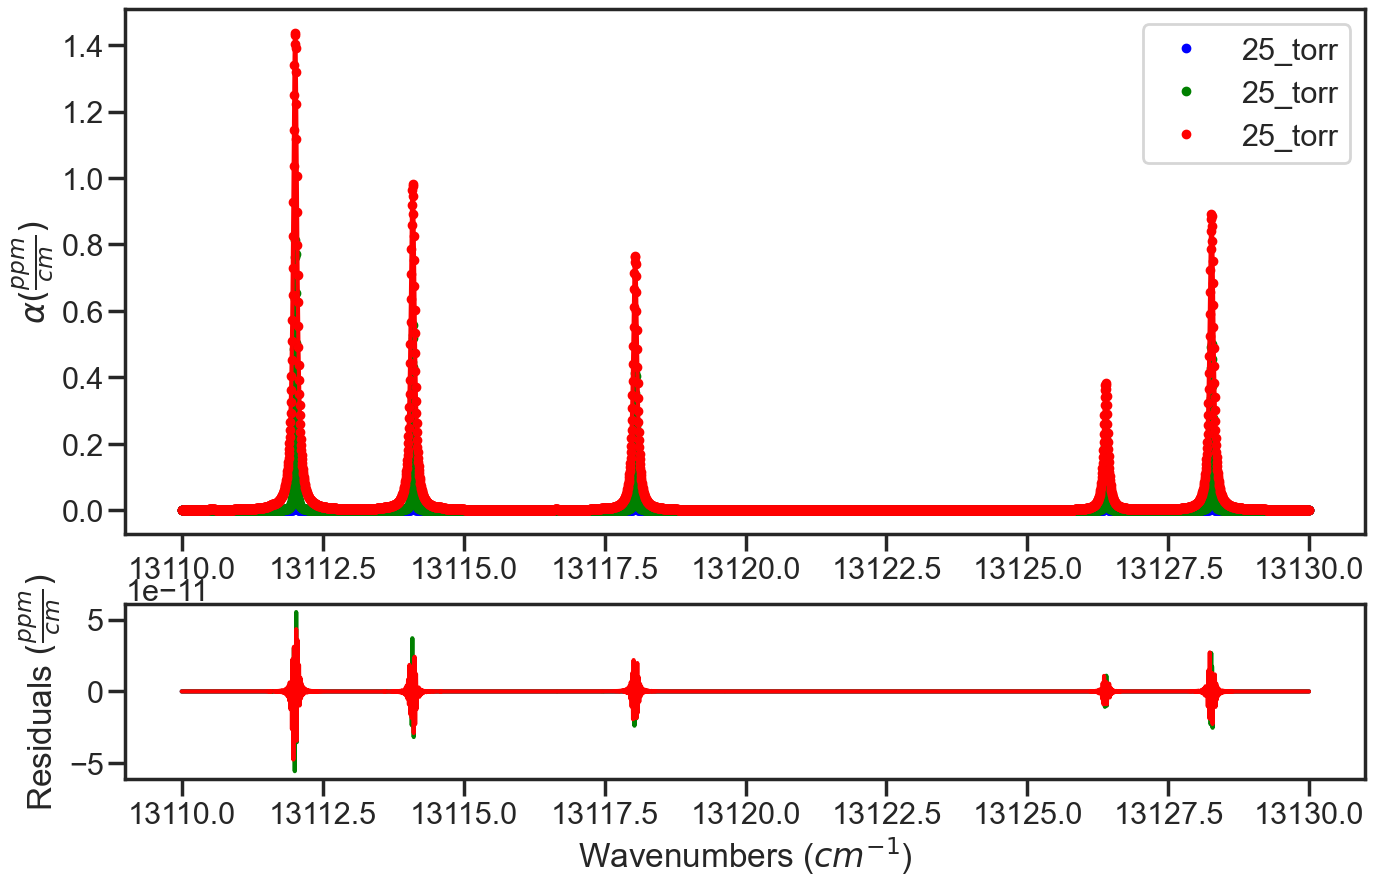

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


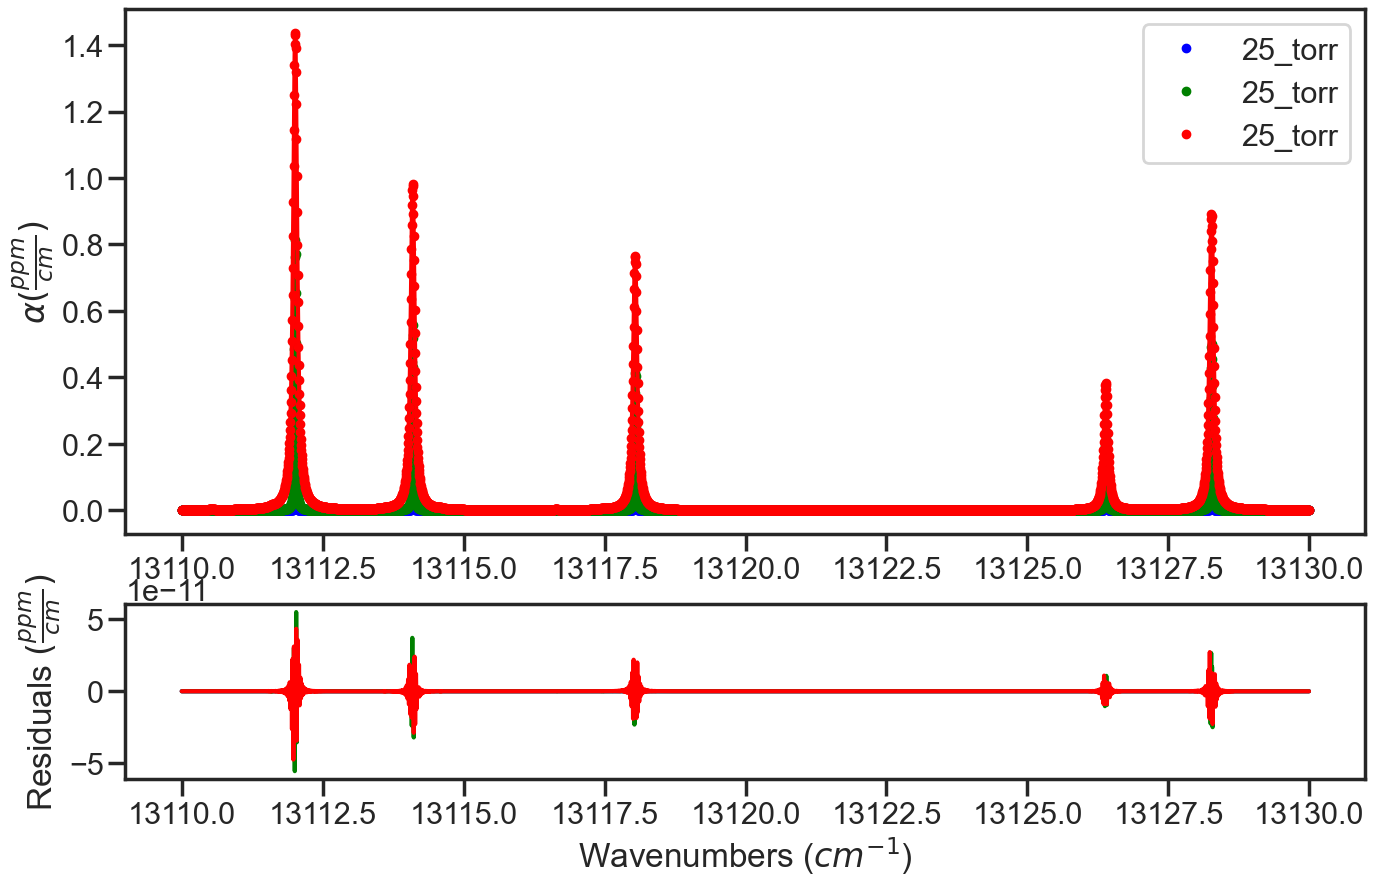

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.865e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.574e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


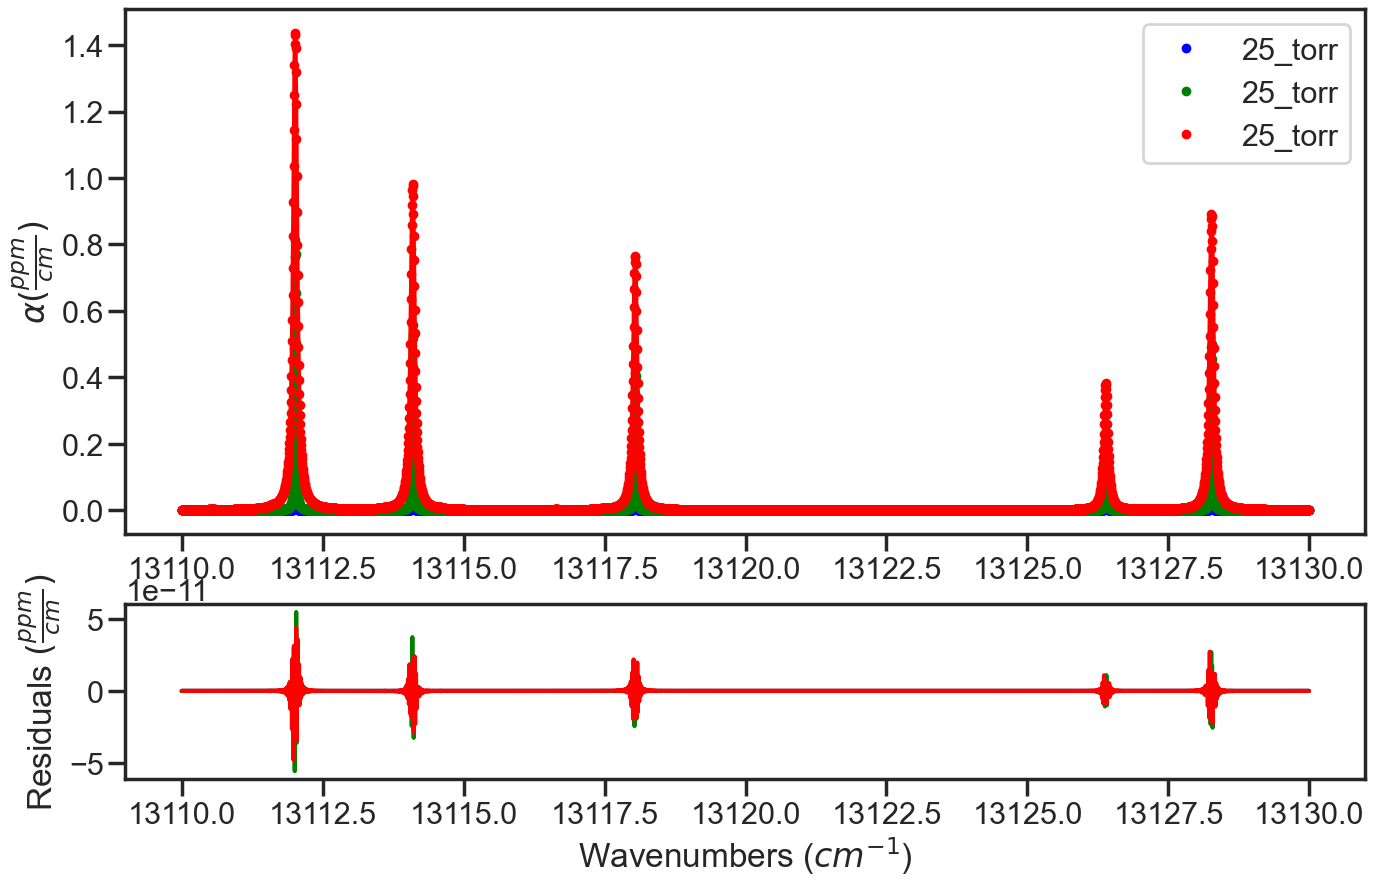

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.866e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.574e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


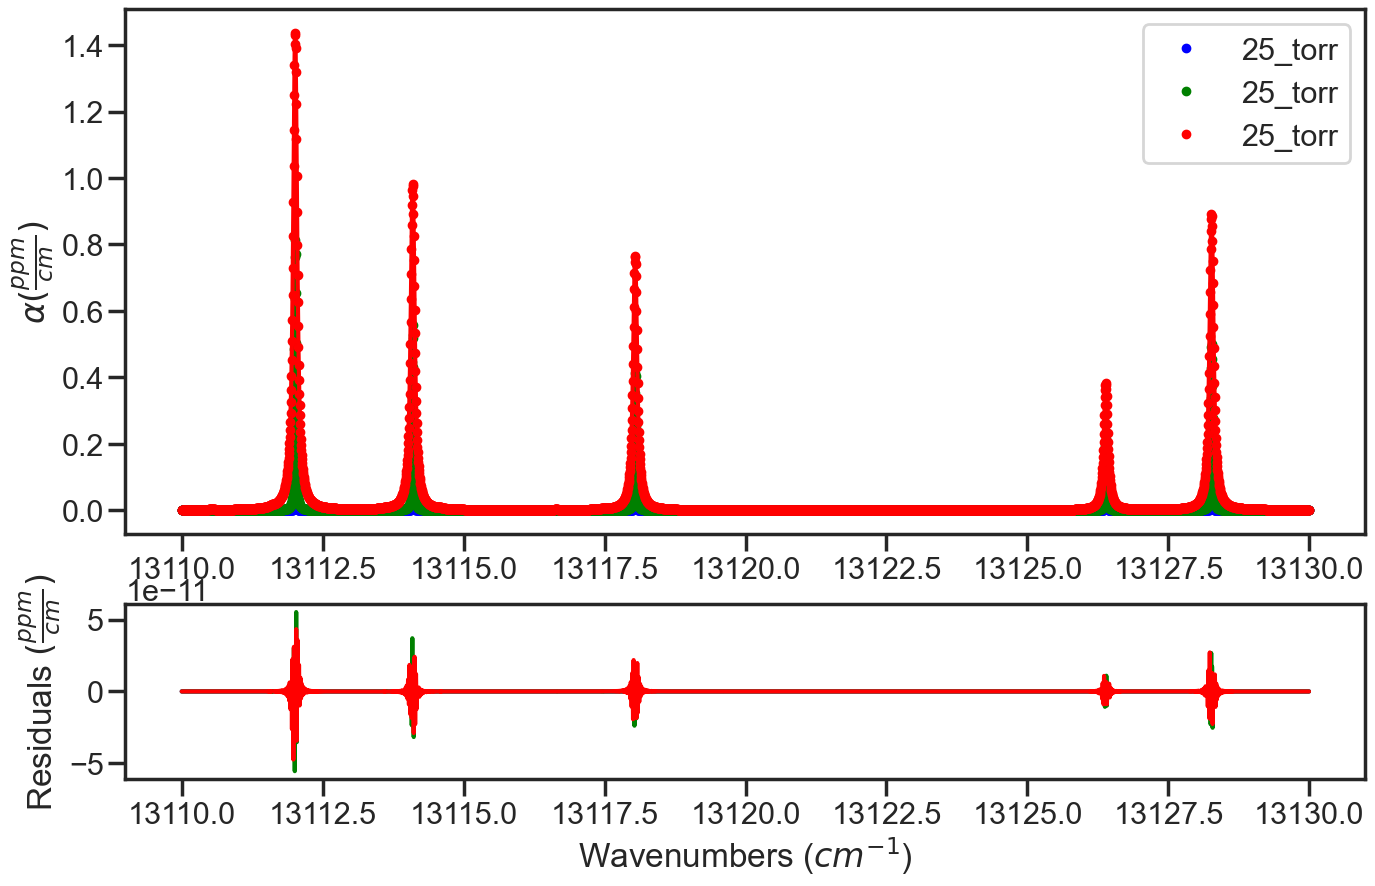

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


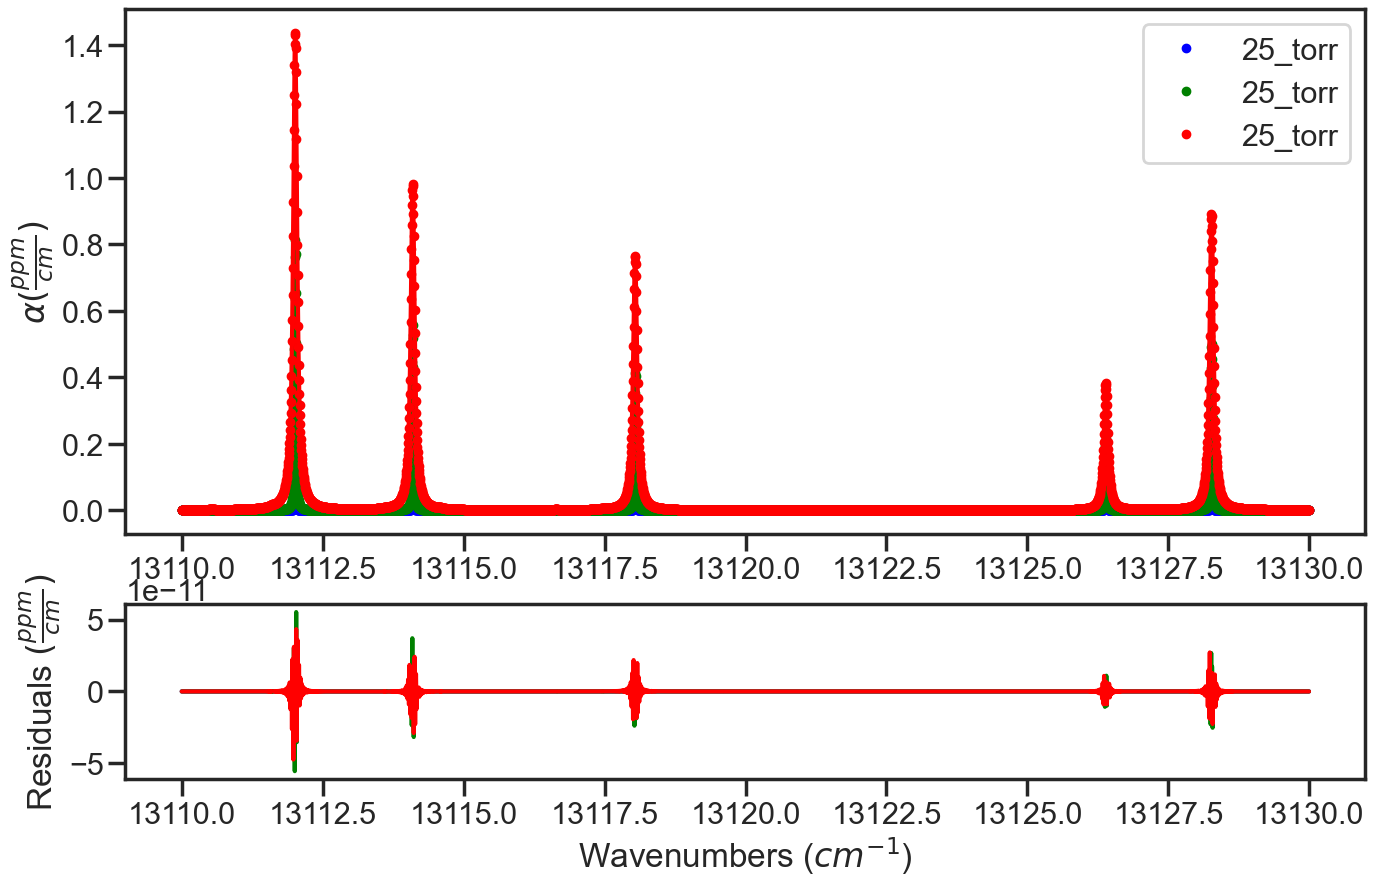

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


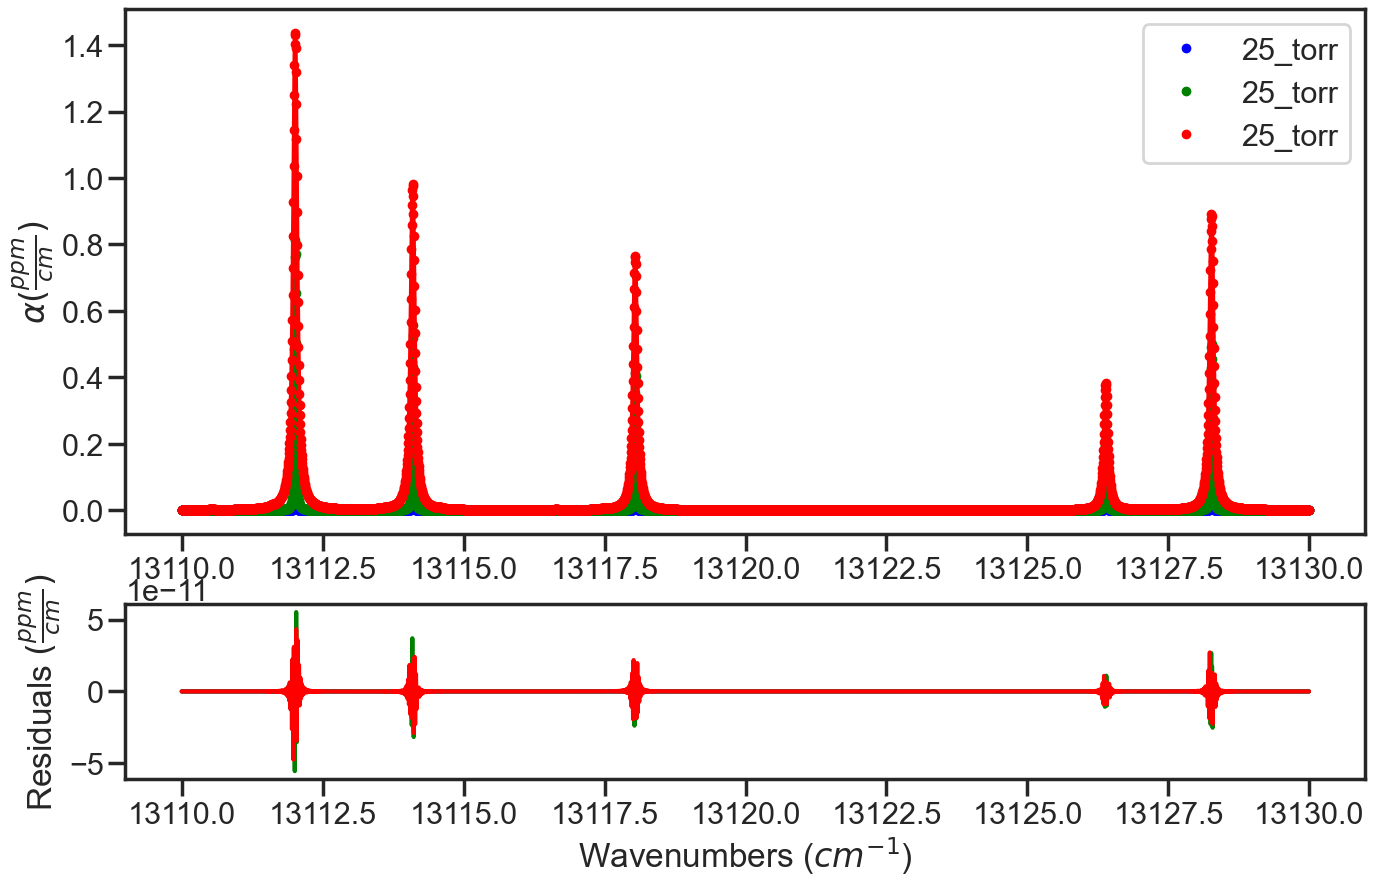

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


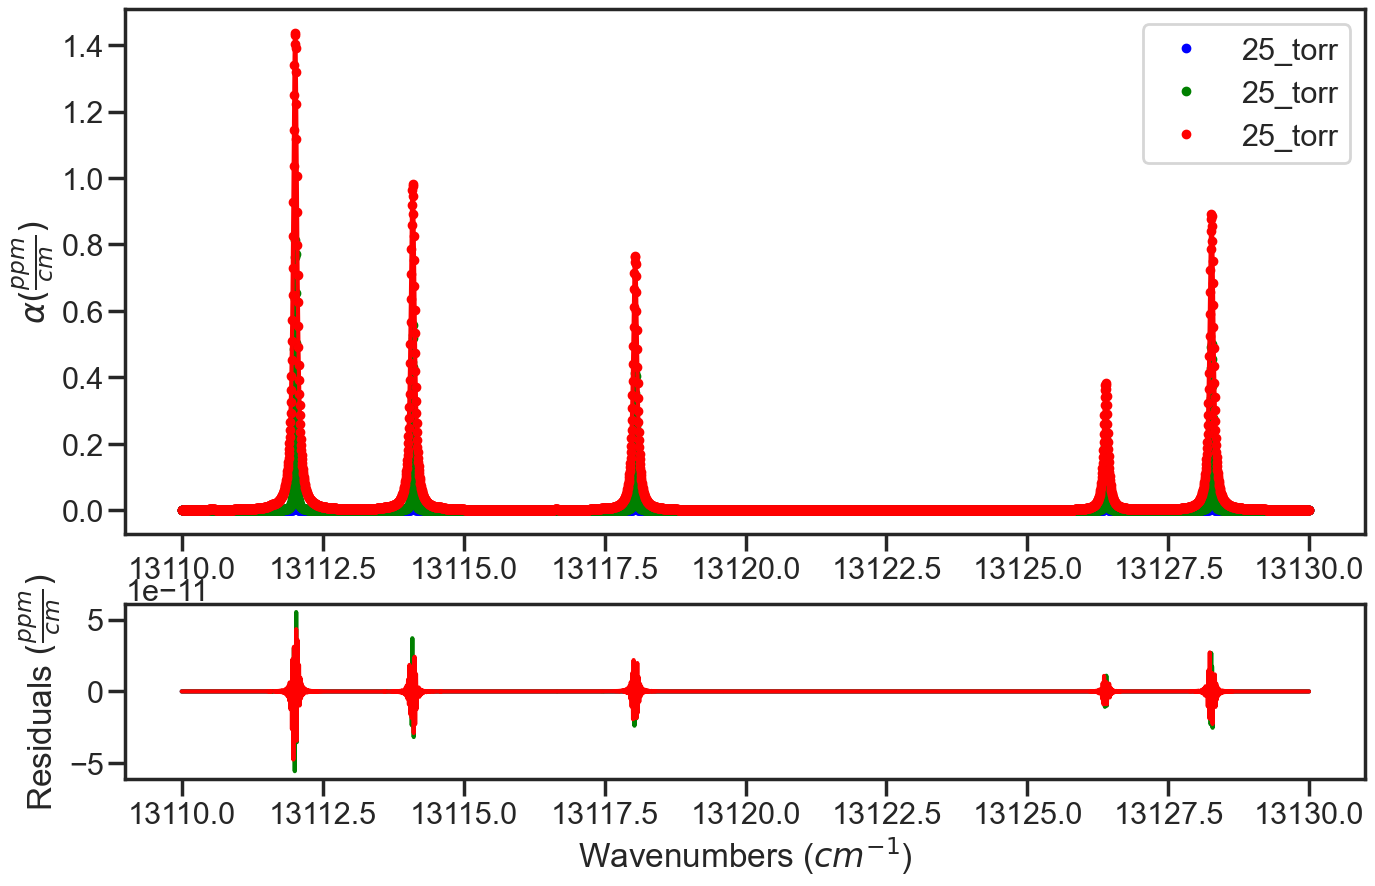

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\miniforge3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


For all line profiles other tha HTP make use of vary_nuOptRe, vary_nuOptRe, vary_nuOptIm, and vary_n_nuOptIm parameters


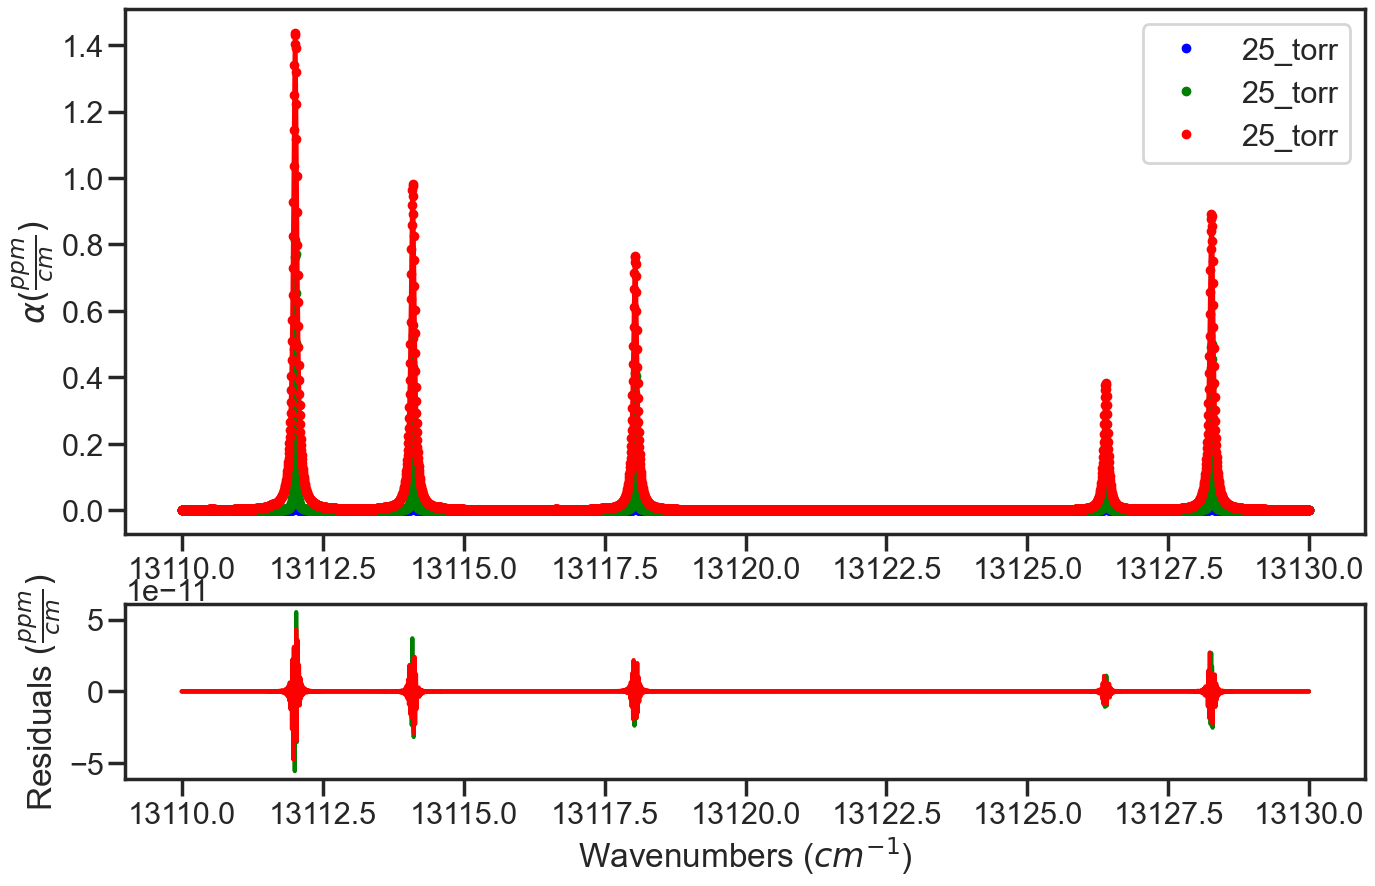

Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_1_0           0.01316     -inf      inf        0    False     None     None
Pressure_2_0            0.1316     -inf      inf        0    False     None     None
Pressure_3_0            0.6579     -inf      inf        0    False     None     None
SD_delta_air_line_42         0     -inf      inf        0    False     None     None
SD_delta_air_line_43         0     -inf      inf        0    False     None     None
SD_delta_air_line_44         0     -inf      inf        0    False     None     None
SD_delta_air_line_45         0     -inf      inf        0    False     None     None
SD_delta_air_line_46         0     -inf      inf        0    False     None     None
SD_delta_air_line_47         0     -inf      inf        0    False     None     None
SD_gamma_air_line_42       0.1     -inf      inf 6.863e-12     True     None     None
SD_gamma_air_line_43      0.12     -inf      inf 8.571e-12    

In [9]:
results_htp = run_performance_test('HTP_Standard', 'HTP', False, iterations=10)
results_mhtp = run_performance_test('mHTP_Standard', 'mHTP', False, iterations=10)
results_mhtp_numba = run_performance_test('mHTP_Numba', 'mHTP', True, iterations=10)